# Comparative Statistical Analysis of Random Bit Sources

## Reproducible comparison of physical and algorithmic entropy sources

This notebook studies seven bit-producing sources:

| Category | Source |
|---|---|
| Physical or acquired | BJT noise, diode noise, SDR I/Q |
| Algorithmic | degree-32 MLS, Python `random`, PyNaCl, ChaCha20 |

Each source is evaluated under three processing strategies:

1. **Raw LSB extraction**  
   The least-significant bit of each integer PCM value is used directly.

2. **Von Neumann debiasing**  
   Non-overlapping pairs are mapped as `01 → 0` and `10 → 1`, while `00`
   and `11` are discarded.

3. **Circular lag-1 XOR whitening**  
   Each bit is XORed with the preceding bit, with wraparound at the beginning.
   This preserves the original sequence length.

The notebook is designed around a fair-comparison principle:

> Sources are compared only over data lengths that are available to every
> member of the relevant transformation family.

Raw and XOR target ten 1,000,000-bit sequences. Von Neumann uses one common
sequence count across all seven sources and targets 55 sequences when enough
data exists.

The notebook produces:

- source diagnostics;
- transformation-retention summaries;
- verified NIST STS input files;
- archived per-variant NIST reports;
- pass-proportion and, when statistically supportable, uniformity heatmaps;
- machine-readable CSV summaries for later analysis.


> ## Reproducibility and data-integrity rules
>
> - No source is padded, repeated, looped, or duplicated.
> - Only complete NIST sequences are used.
> - All variants inside the same transformation family have equal lengths.
> - Absolute local paths are used internally only when an external executable
>   requires them.
> - Notebook output, CSV metadata, errors, and saved logs use relative or
>   redacted paths so local usernames and home-directory details are not
>   disclosed.
> - NIST STS results are statistical evidence, not proof of cryptographic
>   security.


## Research design

The study combines descriptive signal analysis with formal randomness tests.

The signal-analysis stage asks:

- Is the source visibly stationary over the inspected interval?
- Is the raw LSB approximately balanced?
- Does the spectrum contain narrowband interference, periodic structure, or
  strong low-frequency drift?

The NIST stage asks a different question:

- Do fixed-length bitstreams behave consistently with specific statistical
  properties expected from random sequences?

Passing NIST tests does not establish unpredictability. A deterministic
cryptographic generator may pass, while a genuinely physical source may fail
because of bias, correlation, interference, acquisition artifacts, or poor
bit extraction.


In [1]:
from pathlib import Path
import hashlib
import json
import math
import os
import platform
import random
import re
import shutil
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from Crypto.Cipher import ChaCha20
from IPython.display import Markdown, display
from nacl.bindings import randombytes
from scipy.io import wavfile
from scipy.signal import max_len_seq

environment_summary = pd.Series(
    {
        "python_version": platform.python_version(),
        "operating_system": platform.system(),
        "machine_architecture": platform.machine(),
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
    },
    name="value",
)

display(environment_summary)


python_version          3.13.5
operating_system         Linux
machine_architecture    x86_64
numpy_version            2.5.1
pandas_version           3.0.5
Name: value, dtype: str

# 1. Project paths


# 1. Portable project structure

All project resources are addressed relative to the repository root.

The notebook may be launched either from the repository root or from the
`notebooks/` directory. It automatically identifies the correct project root.

Using relative paths improves:

- portability between machines;
- reproducibility in version control;
- privacy in screenshots and publications;
- consistency between local and automated runs.


In [2]:
NOTEBOOK_DIR = Path.cwd().resolve()

if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

DATA_ROOT = PROJECT_ROOT / "data"
INPUT_ROOT = DATA_ROOT / "input"
ALGORITHMIC_ROOT = INPUT_ROOT / "algorithmic"
NIST_INPUT_ROOT = DATA_ROOT / "nist_input"

RESULTS_ROOT = PROJECT_ROOT / "results"
NIST_RESULTS_ROOT = RESULTS_ROOT / "nist"

FIGURES_ROOT = PROJECT_ROOT / "figures"
SOURCE_FIGURE_ROOT = FIGURES_ROOT / "source_diagnostics"

LOGS_ROOT = PROJECT_ROOT / "logs"
NIST_LOG_ROOT = LOGS_ROOT / "nist"

NIST_STS_ROOT = PROJECT_ROOT / "sts-2.1.2"
NIST_ASSESS = NIST_STS_ROOT / "assess"
NIST_WORKING_RESULTS = (
    NIST_STS_ROOT
    / "experiments"
    / "AlgorithmTesting"
)


def relative_project_path(path: Path | str) -> str:
    """
    Return a stable project-relative path for display and metadata.

    Absolute local paths are intentionally not exposed in notebook output.
    """
    candidate = Path(path)

    try:
        return candidate.resolve().relative_to(
            PROJECT_ROOT.resolve()
        ).as_posix()
    except (ValueError, OSError):
        return candidate.name


def redact_local_paths(text: str) -> str:
    """
    Remove project-root and home-directory prefixes from captured text.
    """
    redacted = str(text)

    replacement_pairs = [
        (str(PROJECT_ROOT.resolve()), "."),
        (str(Path.home().resolve()), "~"),
    ]

    for original, replacement in replacement_pairs:
        redacted = redacted.replace(original, replacement)

    return redacted


for directory in [
    ALGORITHMIC_ROOT,
    NIST_INPUT_ROOT,
    RESULTS_ROOT,
    NIST_RESULTS_ROOT,
    FIGURES_ROOT,
    SOURCE_FIGURE_ROOT,
    LOGS_ROOT,
    NIST_LOG_ROOT,
]:
    directory.mkdir(parents=True, exist_ok=True)

path_summary = pd.Series(
    {
        "project_root": ".",
        "input_root": relative_project_path(INPUT_ROOT),
        "nist_input_root": relative_project_path(NIST_INPUT_ROOT),
        "nist_sts_root": relative_project_path(NIST_STS_ROOT),
        "nist_results_root": relative_project_path(NIST_RESULTS_ROOT),
        "figures_root": relative_project_path(FIGURES_ROOT),
    },
    name="relative_path",
)

display(path_summary)


project_root                       .
input_root                data/input
nist_input_root      data/nist_input
nist_sts_root              sts-2.1.2
nist_results_root       results/nist
figures_root                 figures
Name: relative_path, dtype: str

# 2. Configuration

The algorithmic sources are generated with 10,000,000 bits.

A balanced source retains approximately 25% of its bits after Von Neumann
debiasing, so 10,000,000 input bits usually produce approximately 2,500,000
output bits.


# 2. Experimental configuration

A NIST sequence contains 1,000,000 bits.

Raw and XOR request ten sequences, corresponding to 10,000,000 final bits per
variant. Von Neumann requests 55 sequences because a larger collection is
needed for useful second-level uniformity analysis.

When the available recordings are shorter than a requested target, the
notebook uses the maximum complete count available to every source in that
transformation family. Setting `STRICT_TARGET_COUNTS = True` converts a target
shortfall into an error.


In [3]:
NIST_SEQUENCE_BITS = 1_000_000
ALGORITHMIC_SAMPLE_RATE = 48_000

MASTER_SEED = 0x21434
XOR_LAG = 1

WAVEFORM_SAMPLES = 4_096
SPECTRUM_SAMPLES = 65_536

RUN_NIST_STS = True
OVERWRITE_NIST_RESULTS = True
STOP_ON_NIST_ERROR = True
NIST_TIMEOUT_SECONDS = None

MINIMUM_UNIFORMITY_SEQUENCES = 55
TARGET_RAW_SEQUENCE_COUNT = 10
TARGET_XOR_SEQUENCE_COUNT = 10
TARGET_VN_SEQUENCE_COUNT = 55
STRICT_TARGET_COUNTS = False

PHYSICAL_WAV_FILES = {
    "bjt": INPUT_ROOT / "bjt" / "bjt.wav",
    "diode": INPUT_ROOT / "diode" / "diode.wav",
    "sdr": INPUT_ROOT / "sdr" / "sdr.wav",
}

missing_physical_files = [
    path
    for path in PHYSICAL_WAV_FILES.values()
    if not path.is_file()
]

if missing_physical_files:
    raise FileNotFoundError(
        "Missing physical WAV files:\n"
        + "\n".join(str(path) for path in missing_physical_files)
    )


def count_usable_wav_values(
    source: str,
    path: Path,
) -> int:
    """
    Count values that will enter LSB extraction without loading a copy.

    Mono: number of samples.
    SDR I/Q: first two channels interleaved, so 2 values per frame.
    """
    _, samples = wavfile.read(path, mmap=True)

    if samples.ndim == 1:
        return int(samples.shape[0])

    if samples.ndim == 2:
        if source == "sdr":
            if samples.shape[1] < 2:
                raise ValueError(
                    "The SDR WAV must contain at least I and Q channels."
                )
            return int(samples.shape[0] * 2)

        raise ValueError(
            f"{source} is multichannel. Define an explicit channel policy."
        )

    raise ValueError(
        f"Unsupported WAV shape for {source}: {samples.shape}"
    )


physical_value_counts = {
    source: count_usable_wav_values(source, path)
    for source, path in PHYSICAL_WAV_FILES.items()
}

ALGORITHMIC_SOURCE_BITS = min(
    physical_value_counts.values()
)

if ALGORITHMIC_SOURCE_BITS <= XOR_LAG:
    raise RuntimeError(
        "The shortest physical source is too short for analysis."
    )

pd.Series(
    {
        **{
            f"{source}_usable_values": count
            for source, count in physical_value_counts.items()
        },
        "algorithmic_source_bits": ALGORITHMIC_SOURCE_BITS,
        "nist_sequence_bits": NIST_SEQUENCE_BITS,
        "minimum_uniformity_sequences": (
            MINIMUM_UNIFORMITY_SEQUENCES
        ),
        "run_nist_sts": RUN_NIST_STS,
    },
    name="value",
)


bjt_usable_values               13369268
diode_usable_values              8234837
sdr_usable_values               30146560
algorithmic_source_bits          8234837
nist_sequence_bits               1000000
minimum_uniformity_sequences          55
run_nist_sts                        True
Name: value, dtype: object

# 3. Shared utilities


# 3. Validation and provenance utilities

Every transformation accepts only a one-dimensional binary array containing
zeros and ones. Early validation prevents silent errors such as:

- signed PCM amplitudes being mistaken for already extracted bits;
- multidimensional arrays entering bit transforms;
- malformed values propagating into exported NIST files.

SHA-256 hashes are recorded for reproducibility. A hash does not describe
randomness; it only verifies that the exact same file was used in later runs.


In [4]:
def validate_bits(
    bits: np.ndarray,
    name: str = "bitstream",
) -> np.ndarray:
    bits = np.asarray(bits)

    if bits.ndim != 1:
        raise ValueError(
            f"{name} must be one-dimensional; received {bits.shape}."
        )

    if not np.all((bits == 0) | (bits == 1)):
        raise ValueError(
            f"{name} contains values other than 0 and 1."
        )

    return bits.astype(np.uint8, copy=False)


def bytes_to_bits(
    data: bytes,
    required_bits: int | None = None,
) -> np.ndarray:
    bits = np.unpackbits(
        np.frombuffer(data, dtype=np.uint8),
        bitorder="big",
    )

    if required_bits is not None:
        bits = bits[:required_bits]

    return bits.astype(np.uint8, copy=False)


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()

    with path.open("rb") as input_file:
        for chunk in iter(
            lambda: input_file.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


# 4. Algorithmic WAV helpers


# 4. Representing algorithmic sources as WAV files

The algorithmic sources are saved as unsigned 8-bit PCM WAV files whose sample
values are exactly zero or one.

This is not intended to model an analog waveform. It provides a uniform file
interface so the same loading, registration, hashing, diagnostics, and LSB
extraction code can be applied to both acquired and generated sources.


In [5]:
def save_bits_as_wav(
    path: Path,
    bits: np.ndarray,
    sample_rate: int = ALGORITHMIC_SAMPLE_RATE,
) -> None:
    bits = validate_bits(bits, path.stem)
    path.parent.mkdir(parents=True, exist_ok=True)
    wavfile.write(path, sample_rate, bits.astype(np.uint8))


def load_generated_wav(
    path: Path,
) -> tuple[int, np.ndarray]:
    sample_rate, samples = wavfile.read(path)

    if samples.ndim != 1:
        raise ValueError(
            f"{path.name} must be mono."
        )

    if samples.dtype != np.uint8:
        raise TypeError(
            f"{path.name} must use uint8 PCM."
        )

    return sample_rate, validate_bits(samples, path.name)


def generated_wav_is_valid(
    path: Path,
    expected_bits: int,
) -> bool:
    if not path.is_file():
        return False

    try:
        _, bits = load_generated_wav(path)
    except Exception:
        return False

    return len(bits) == expected_bits


# 5. Generate algorithmic sources


In [6]:
ALGORITHMIC_DIRECTORIES = {
    "mls": ALGORITHMIC_ROOT / "mls",
    "python_random": ALGORITHMIC_ROOT / "python_random",
    "pynacl": ALGORITHMIC_ROOT / "pynacl",
    "pycryptodome": ALGORITHMIC_ROOT / "pycryptodome",
}

for directory in ALGORITHMIC_DIRECTORIES.values():
    directory.mkdir(parents=True, exist_ok=True)


## 5.1 Degree-32 MLS


## 5.1 Maximal-length sequence

A degree-32 maximal-length sequence is deterministic and periodic. It has
strong balance and run-length properties over its full period, but it is not a
cryptographically secure random source.

Including it provides a useful structured reference: a sequence may look
statistically strong in several tests while remaining fully predictable from
its recurrence.


In [7]:
def generate_mls_bits(
    number_of_bits: int,
    initial_state: int,
) -> np.ndarray:
    if not 0 < initial_state < 2**32:
        raise ValueError(
            "initial_state must be a nonzero 32-bit integer."
        )

    state = np.array(
        [
            (initial_state >> position) & 1
            for position in range(31, -1, -1)
        ],
        dtype=np.int8,
    )

    sequence, _ = max_len_seq(
        nbits=32,
        state=state,
        length=number_of_bits,
    )

    return sequence.astype(np.uint8)


MLS_WAV_PATH = ALGORITHMIC_DIRECTORIES["mls"] / "mls.wav"
mls_bits = generate_mls_bits(
    ALGORITHMIC_SOURCE_BITS,
    MASTER_SEED,
)

if not generated_wav_is_valid(
    MLS_WAV_PATH,
    ALGORITHMIC_SOURCE_BITS,
):
    save_bits_as_wav(MLS_WAV_PATH, mls_bits)

_, loaded_mls_bits = load_generated_wav(MLS_WAV_PATH)

if not np.array_equal(mls_bits, loaded_mls_bits):
    raise RuntimeError("MLS WAV round-trip failed.")

print("MLS bits:", len(loaded_mls_bits))


MLS bits: 8234837


## 5.2 Python `random`


## 5.2 Python pseudorandom generator

Python's `random` module is designed for simulation and general-purpose
sampling. It is deterministic when initialized with the same seed and should
not be interpreted as a cryptographic entropy source.

A fixed seed is used so the experiment can be reproduced exactly.


In [8]:
def generate_python_random_bits(
    number_of_bits: int,
    seed: int,
) -> np.ndarray:
    generator = random.Random(seed)
    byte_count = math.ceil(number_of_bits / 8)

    generated_bytes = bytes(
        generator.getrandbits(8)
        for _ in range(byte_count)
    )

    return bytes_to_bits(
        generated_bytes,
        required_bits=number_of_bits,
    )


PYTHON_RANDOM_WAV_PATH = (
    ALGORITHMIC_DIRECTORIES["python_random"]
    / "python_random.wav"
)

python_random_bits = generate_python_random_bits(
    ALGORITHMIC_SOURCE_BITS,
    MASTER_SEED,
)

if not generated_wav_is_valid(
    PYTHON_RANDOM_WAV_PATH,
    ALGORITHMIC_SOURCE_BITS,
):
    save_bits_as_wav(
        PYTHON_RANDOM_WAV_PATH,
        python_random_bits,
    )

_, loaded_python_random_bits = load_generated_wav(
    PYTHON_RANDOM_WAV_PATH
)

if not np.array_equal(
    python_random_bits,
    loaded_python_random_bits,
):
    raise RuntimeError(
        "Python random WAV round-trip failed."
    )

print("Python random bits:", len(loaded_python_random_bits))


Python random bits: 8234837


## 5.3 PyNaCl


## 5.3 PyNaCl random bytes

PyNaCl exposes operating-system-backed cryptographic random-byte generation.
Unlike the seeded Python source, a new file is generated only when a valid
saved WAV does not already exist. Reusing the saved file is essential for
reproducible comparisons across notebook runs.


In [9]:
def generate_pynacl_bits(
    number_of_bits: int,
) -> np.ndarray:
    byte_count = math.ceil(number_of_bits / 8)

    return bytes_to_bits(
        randombytes(byte_count),
        required_bits=number_of_bits,
    )


PYNACL_WAV_PATH = (
    ALGORITHMIC_DIRECTORIES["pynacl"]
    / "pynacl.wav"
)

if generated_wav_is_valid(
    PYNACL_WAV_PATH,
    ALGORITHMIC_SOURCE_BITS,
):
    _, pynacl_bits = load_generated_wav(
        PYNACL_WAV_PATH
    )
else:
    pynacl_bits = generate_pynacl_bits(
        ALGORITHMIC_SOURCE_BITS
    )
    save_bits_as_wav(PYNACL_WAV_PATH, pynacl_bits)

print("PyNaCl bits:", len(pynacl_bits))


PyNaCl bits: 8234837


## 5.4 PyCryptodome ChaCha20


## 5.4 ChaCha20 reference stream

ChaCha20 produces a deterministic keystream from a key and nonce. In this
notebook, the key and nonce are stored solely to reproduce the statistical
test stream.

The stored values must never be reused for real encryption. The purpose here
is to compare a modern cryptographic stream with physical and noncryptographic
sources under identical statistical processing.


In [10]:
PYCRYPTODOME_DIRECTORY = (
    ALGORITHMIC_DIRECTORIES["pycryptodome"]
)

PYCRYPTODOME_WAV_PATH = (
    PYCRYPTODOME_DIRECTORY
    / "pycryptodome_chacha20.wav"
)

PYCRYPTODOME_METADATA_PATH = (
    PYCRYPTODOME_DIRECTORY
    / "pycryptodome_chacha20_metadata.json"
)


def generate_chacha20_bits(
    number_of_bits: int,
    key: bytes,
    nonce: bytes,
) -> np.ndarray:
    byte_count = math.ceil(number_of_bits / 8)

    cipher = ChaCha20.new(
        key=key,
        nonce=nonce,
    )

    stream = cipher.encrypt(bytes(byte_count))

    return bytes_to_bits(
        stream,
        required_bits=number_of_bits,
    )


In [11]:
if PYCRYPTODOME_METADATA_PATH.is_file():
    metadata = json.loads(
        PYCRYPTODOME_METADATA_PATH.read_text(
            encoding="utf-8"
        )
    )

    chacha_key = bytes.fromhex(metadata["key_hex"])
    chacha_nonce = bytes.fromhex(metadata["nonce_hex"])
else:
    chacha_key = randombytes(32)
    chacha_nonce = randombytes(8)

    metadata = {
        "algorithm": "ChaCha20",
        "purpose": "Statistical-test stream only",
        "warning": "Do not use this key and nonce for real encryption",
        "key_hex": chacha_key.hex(),
        "nonce_hex": chacha_nonce.hex(),
    }

    PYCRYPTODOME_METADATA_PATH.write_text(
        json.dumps(metadata, indent=2),
        encoding="utf-8",
    )

pycryptodome_bits = generate_chacha20_bits(
    ALGORITHMIC_SOURCE_BITS,
    chacha_key,
    chacha_nonce,
)

if not generated_wav_is_valid(
    PYCRYPTODOME_WAV_PATH,
    ALGORITHMIC_SOURCE_BITS,
):
    save_bits_as_wav(
        PYCRYPTODOME_WAV_PATH,
        pycryptodome_bits,
    )

_, loaded_pycryptodome_bits = load_generated_wav(
    PYCRYPTODOME_WAV_PATH
)

if not np.array_equal(
    pycryptodome_bits,
    loaded_pycryptodome_bits,
):
    raise RuntimeError(
        "PyCryptodome WAV round-trip failed."
    )

print("PyCryptodome bits:", len(loaded_pycryptodome_bits))


PyCryptodome bits: 8234837


# 6. Register all seven WAV files


# 6. Source registry and provenance

The registry creates one canonical mapping from source names to input files.
Each entry records:

- source category;
- project-relative file path;
- file size;
- SHA-256 hash.

This table is the provenance layer for the rest of the experiment. Results
should be interpreted only together with the exact registered input hashes.


In [12]:
ALGORITHMIC_WAV_FILES = {
    "mls": MLS_WAV_PATH,
    "python_random": PYTHON_RANDOM_WAV_PATH,
    "pynacl": PYNACL_WAV_PATH,
    "pycryptodome": PYCRYPTODOME_WAV_PATH,
}

ALL_WAV_FILES = {
    **ALGORITHMIC_WAV_FILES,
    **PHYSICAL_WAV_FILES,
}

missing_files = [
    relative_project_path(path)
    for path in ALL_WAV_FILES.values()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "Missing WAV files:\n"
        + "\n".join(missing_files)
    )

source_registry = pd.DataFrame(
    [
        {
            "source": source,
            "category": (
                "algorithmic"
                if source in ALGORITHMIC_WAV_FILES
                else "physical"
            ),
            "path": relative_project_path(path),
            "size_mib": path.stat().st_size / (1024**2),
            "sha256": sha256_file(path),
        }
        for source, path in ALL_WAV_FILES.items()
    ]
)

source_registry.to_csv(
    RESULTS_ROOT / "source_registry.csv",
    index=False,
)

source_registry


,source,category,path,size_mib,sha256
0,mls,algorithmic,data/input/algorithmic/mls/mls.wav,7.853395,906c9a7fb9a8eba23f91092a891a59a0d9108c63ac3c40...
1,python_random,algorithmic,data/input/algorithmic/python_random/python_ra...,7.853395,caad29c57962079073f6adf95c0ef6e5c30a472b2d5280...
2,pynacl,algorithmic,data/input/algorithmic/pynacl/pynacl.wav,7.853395,b3bd74428e0b7ca63cc2c5168ed6c19f96d7f4e573639b...
3,pycryptodome,algorithmic,data/input/algorithmic/pycryptodome/pycryptodo...,7.853395,34aa70649bd7b5b76f724e870406a8e75495145bc6706a...
4,bjt,physical,data/input/bjt/bjt.wav,25.499897,2244cc8ad04c19f34ff6ac151e8453f560d0720b7cfeaa...
5,diode,physical,data/input/diode/diode.wav,15.706747,5847c4bc48fcac386f396d3e98130d051acb9df7876f4b...
6,sdr,physical,data/input/sdr/sdr.wav,57.500042,c2cda2eaa6b73ee0261d49a9792abf5952ddfebcc8ee24...


# 7. Load WAV files

Mono WAV files are used directly.

For the SDR WAV, the first two channels are interpreted as I and Q:

- bit extraction uses frame-wise interleaving: `I0, Q0, I1, Q1, ...`;
- the waveform diagnostic plots I and Q separately;
- the spectrum uses the complex baseband signal \(I + jQ\).

This preserves the correct SDR sampling rate and avoids treating interleaved
I/Q values as a real-valued waveform.


# 7. WAV loading and SDR treatment

Mono recordings are loaded directly.

The SDR recording is treated as complex I/Q data:

- I and Q are preserved as separate channels for waveform diagnostics;
- the channels are interleaved only for bit extraction;
- the frequency-domain diagnostic uses the complex sequence \(I+jQ\).

Treating interleaved I/Q values as one ordinary real-valued waveform would
produce an incorrect frequency axis and misleading spectral structure.


In [13]:
SOURCE_CHANNELS = {
    "sdr": "iq",
}


def load_source_wav(
    source: str,
    path: Path,
    category: str,
    channel_policy: int | str | None = None,
) -> dict:
    sample_rate, original_samples = wavfile.read(path)
    original_samples = np.asarray(original_samples)

    iq_samples = None

    if original_samples.ndim == 1:
        selected_samples = original_samples
        applied_policy = "mono"

    elif original_samples.ndim == 2:
        if channel_policy == "iq":
            if original_samples.shape[1] < 2:
                raise ValueError(
                    f"{source} requires at least two channels for I/Q."
                )

            iq_samples = original_samples[:, :2]
            selected_samples = iq_samples.reshape(-1)
            applied_policy = "interleave_IQ_for_bits"

        elif channel_policy == "interleave":
            selected_samples = original_samples.reshape(-1)
            applied_policy = "interleave_all_channels"

        elif isinstance(channel_policy, int):
            if not 0 <= channel_policy < original_samples.shape[1]:
                raise ValueError(
                    f"Invalid channel {channel_policy} for {source}."
                )

            selected_samples = original_samples[:, channel_policy]
            applied_policy = f"channel_{channel_policy}"

        else:
            raise ValueError(
                f"{source} has {original_samples.shape[1]} channels. "
                "Set an explicit channel policy."
            )

    else:
        raise ValueError(
            f"Unsupported WAV shape for {source}: "
            f"{original_samples.shape}"
        )

    if not np.issubdtype(selected_samples.dtype, np.integer):
        raise TypeError(
            f"{source} must use integer PCM."
        )

    if category == "algorithmic":
        validate_bits(selected_samples, source)

    return {
        "source": source,
        "category": category,
        "path": path,
        "sample_rate": int(sample_rate),
        "samples": np.asarray(selected_samples),
        "original_samples": original_samples,
        "iq_samples": iq_samples,
        "dtype": str(selected_samples.dtype),
        "original_shape": tuple(original_samples.shape),
        "channel_policy": applied_policy,
    }


In [14]:
loaded_sources = {}

for source, path in ALL_WAV_FILES.items():
    category = (
        "algorithmic"
        if source in ALGORITHMIC_WAV_FILES
        else "physical"
    )

    loaded_sources[source] = load_source_wav(
        source=source,
        path=path,
        category=category,
        channel_policy=SOURCE_CHANNELS.get(source),
    )

all_source_metadata = pd.DataFrame(
    [
        {
            "source": source,
            "category": entry["category"],
            "sample_rate_hz": entry["sample_rate"],
            "dtype": entry["dtype"],
            "original_shape": str(entry["original_shape"]),
            "channel_policy": entry["channel_policy"],
            "sample_count": len(entry["samples"]),
            "minimum": int(np.min(entry["samples"])),
            "maximum": int(np.max(entry["samples"])),
            "mean": float(np.mean(entry["samples"])),
            "standard_deviation": float(
                np.std(entry["samples"])
            ),
        }
        for source, entry in loaded_sources.items()
    ]
)

all_source_metadata.to_csv(
    RESULTS_ROOT / "all_source_metadata.csv",
    index=False,
)

all_source_metadata


,source,category,sample_rate_hz,dtype,original_shape,channel_policy,sample_count,minimum,maximum,mean,standard_deviation
0,mls,algorithmic,48000,uint8,"(8234837,)",mono,8234837,0,1,0.500185,0.500000
1,python_random,algorithmic,48000,uint8,"(8234837,)",mono,8234837,0,1,0.499885,0.500000
2,pynacl,algorithmic,48000,uint8,"(8234837,)",mono,8234837,0,1,0.500176,0.500000
3,pycryptodome,algorithmic,48000,uint8,"(8234837,)",mono,8234837,0,1,0.499967,0.500000
4,bjt,physical,44100,int16,"(13369268,)",mono,13369268,-4206,1336,280.357610,270.695220
5,diode,physical,44100,int16,"(8234837,)",mono,8234837,-5,528,320.700292,70.466418
6,sdr,physical,2000000,int16,"(15073280, 2)",interleave_IQ_for_bits,30146560,-32544,32767,-0.034581,9006.817789


# 8. LSB extraction


# 8. Least-significant-bit extraction

For integer PCM data, the least-significant bit is extracted by masking the
integer representation with one.

The LSB is attractive because it is sensitive to small amplitude variations,
but it can also expose digitizer artifacts, deterministic quantization
patterns, electrical interference, and correlations between adjacent samples.

The raw LSB should therefore be treated as a candidate bitstream, not as
validated entropy.


In [15]:
def extract_lsb(
    samples: np.ndarray,
    bit_index: int = 0,
) -> np.ndarray:
    samples = np.asarray(samples)

    if samples.ndim != 1:
        raise ValueError(
            "LSB extraction requires a one-dimensional array."
        )

    if not np.issubdtype(samples.dtype, np.integer):
        raise TypeError(
            "LSB extraction requires integer PCM."
        )

    return (
        (samples.astype(np.int64) >> bit_index) & 1
    ).astype(np.uint8)


raw_bitstreams = {
    source: extract_lsb(entry["samples"])
    for source, entry in loaded_sources.items()
}


# 9. Combined diagnostics per WAV

Each source produces one three-panel figure:

1. waveform or noise samples;
2. extracted zero/one counts and proportions;
3. frequency spectrum.

For SDR I/Q data, the waveform panel shows I and Q separately and the spectrum
is centered from \(-f_s/2\) to \(f_s/2\).


# 9. Source diagnostics

Each source receives one three-panel diagnostic figure.

### Waveform panel

This reveals clipping, offsets, drift, periodic interference, and obvious
nonstationarity over the displayed interval.

### LSB balance panel

A proportion near 0.5 is desirable, but balance alone is insufficient.
A perfectly alternating `0101...` sequence is balanced and still completely
predictable.

### Spectrum panel

Narrow peaks suggest periodic interference or deterministic structure.
Broadband appearance is encouraging, but a flat-looking spectrum alone does
not establish independence or unpredictability.


In [16]:
def compute_real_spectrum(
    samples: np.ndarray,
    sample_rate: int,
    maximum_samples: int = SPECTRUM_SAMPLES,
) -> tuple[np.ndarray, np.ndarray]:
    samples = np.asarray(samples, dtype=np.float64)
    count = min(maximum_samples, len(samples))

    if count < 2:
        raise ValueError("At least two samples are required.")

    segment = samples[:count]
    segment = segment - np.mean(segment)

    window = np.hanning(count)
    spectrum = np.fft.rfft(segment * window)

    normalization = np.sum(window)
    magnitude = np.abs(spectrum)

    if normalization > 0:
        magnitude = magnitude / normalization

    frequencies = np.fft.rfftfreq(
        count,
        d=1.0 / sample_rate,
    )

    magnitude_db = 20.0 * np.log10(
        np.maximum(magnitude, np.finfo(np.float64).tiny)
    )

    return frequencies, magnitude_db


def compute_iq_spectrum(
    iq_samples: np.ndarray,
    sample_rate: int,
    maximum_samples: int = SPECTRUM_SAMPLES,
) -> tuple[np.ndarray, np.ndarray]:
    iq_samples = np.asarray(iq_samples)

    if iq_samples.ndim != 2 or iq_samples.shape[1] < 2:
        raise ValueError(
            "I/Q spectrum requires an array with I and Q columns."
        )

    count = min(maximum_samples, len(iq_samples))

    if count < 2:
        raise ValueError("At least two I/Q frames are required.")

    complex_signal = (
        iq_samples[:count, 0].astype(np.float64)
        + 1j * iq_samples[:count, 1].astype(np.float64)
    )
    complex_signal = complex_signal - np.mean(complex_signal)

    window = np.hanning(count)
    spectrum = np.fft.fftshift(
        np.fft.fft(complex_signal * window)
    )

    normalization = np.sum(window)
    magnitude = np.abs(spectrum)

    if normalization > 0:
        magnitude = magnitude / normalization

    frequencies = np.fft.fftshift(
        np.fft.fftfreq(
            count,
            d=1.0 / sample_rate,
        )
    )

    magnitude_db = 20.0 * np.log10(
        np.maximum(magnitude, np.finfo(np.float64).tiny)
    )

    return frequencies, magnitude_db


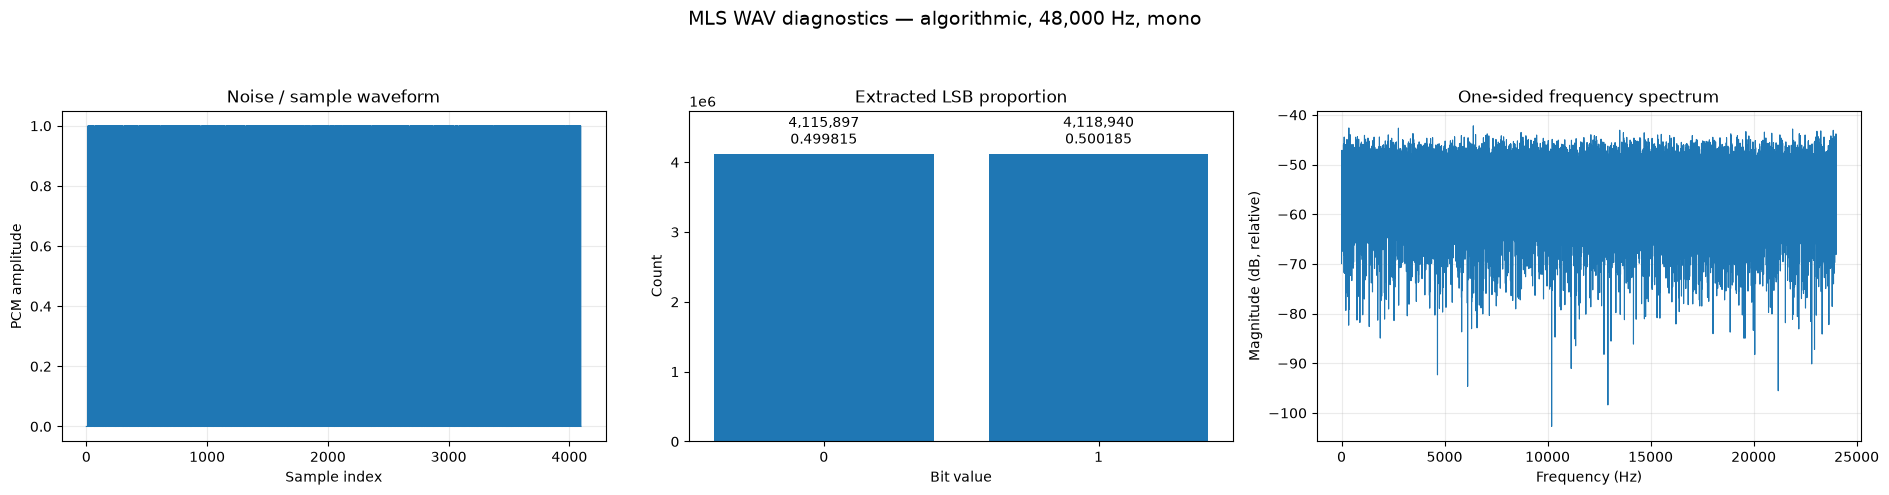

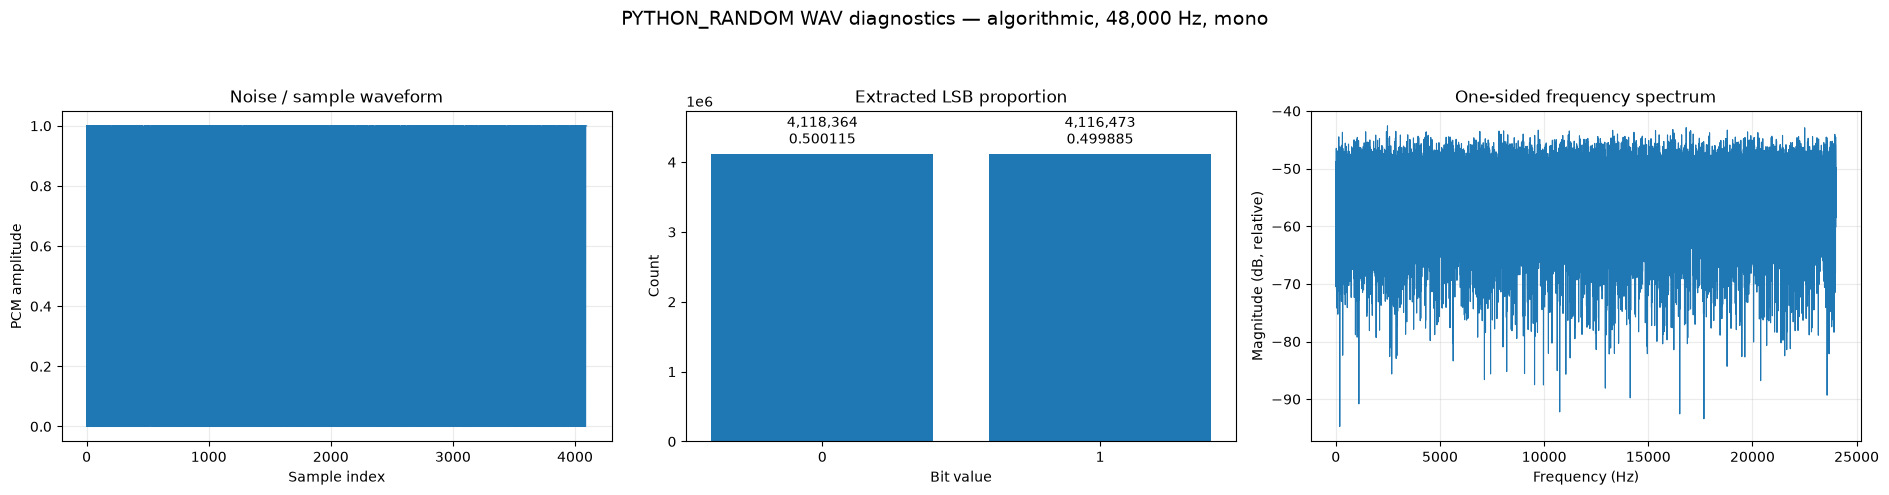

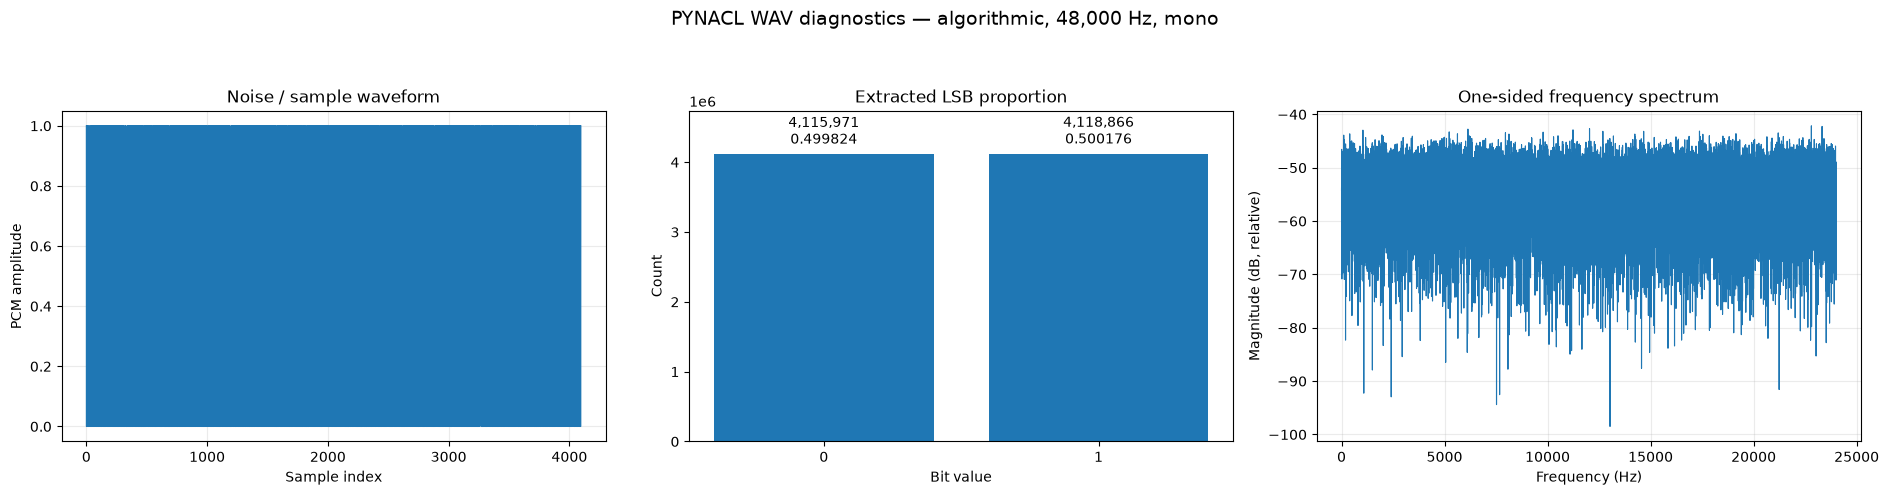

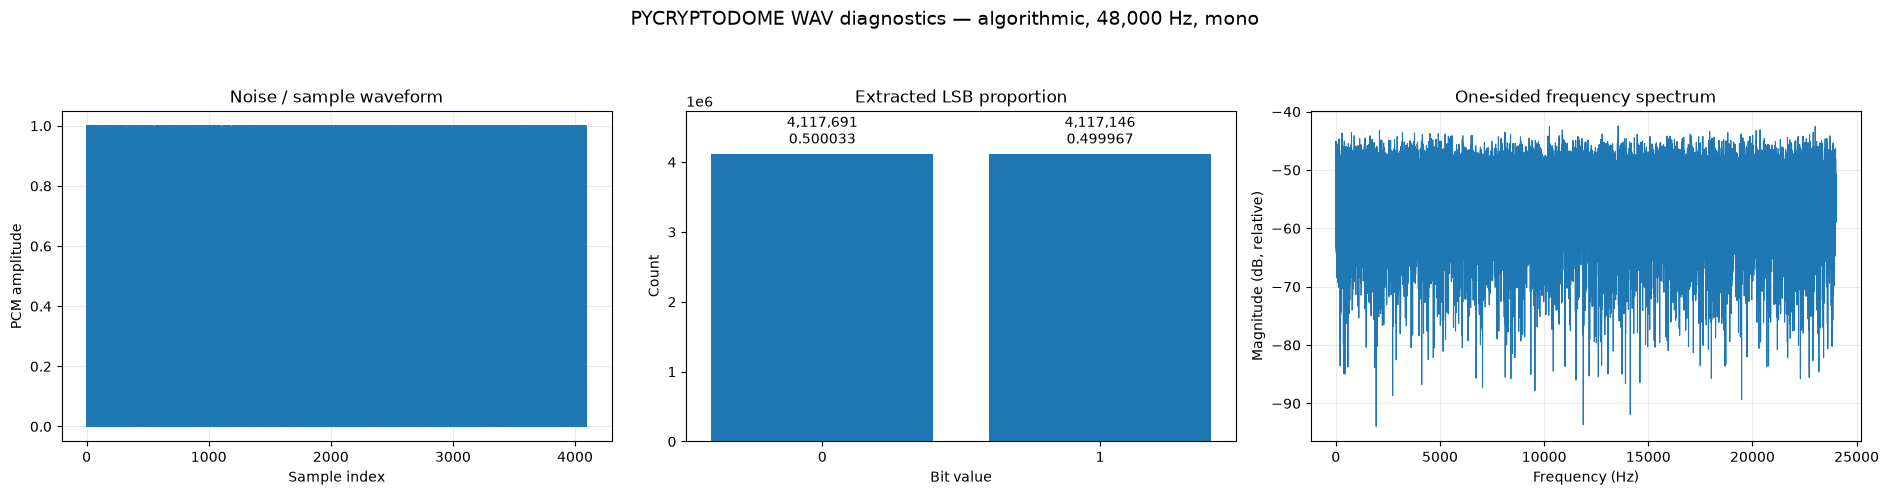

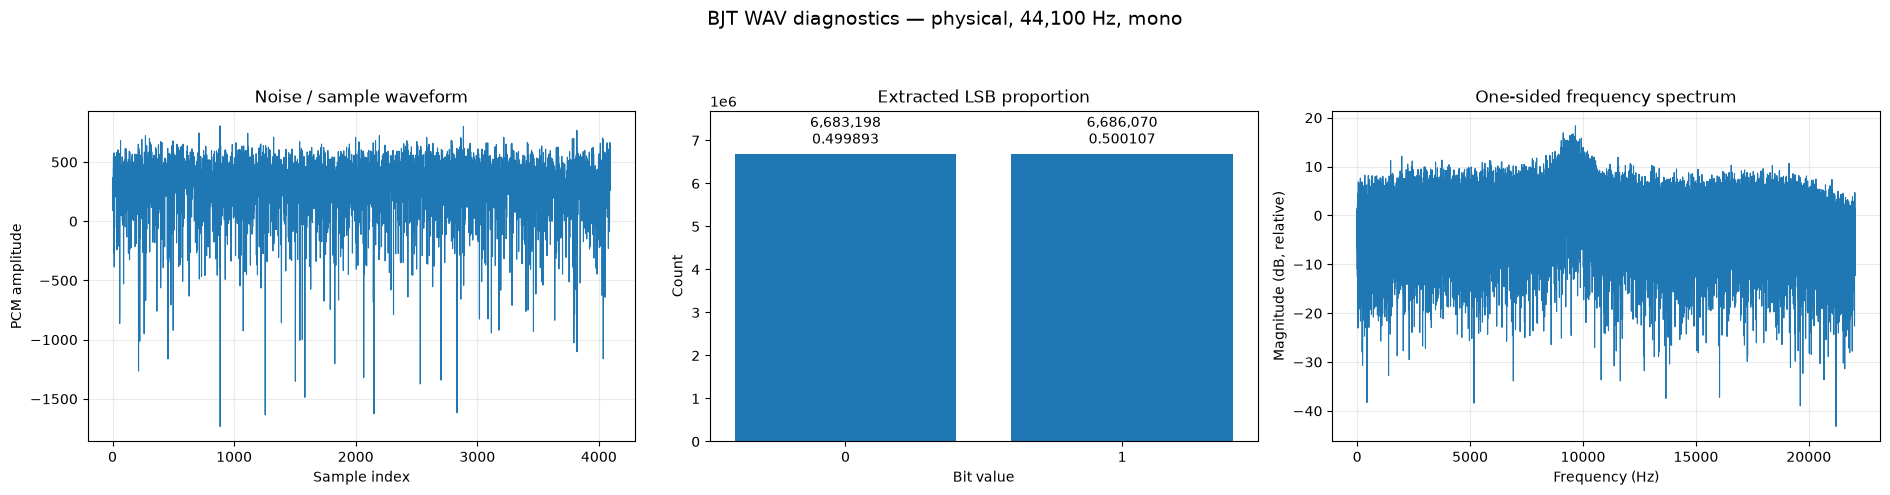

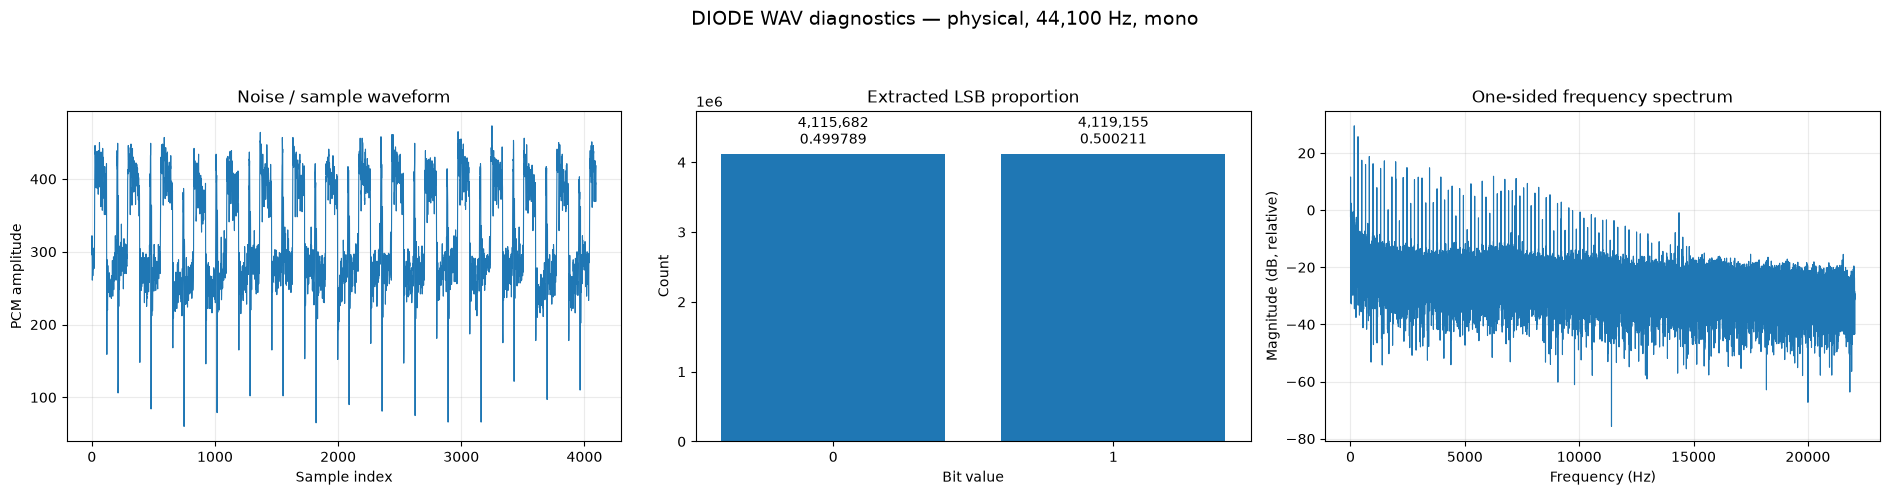

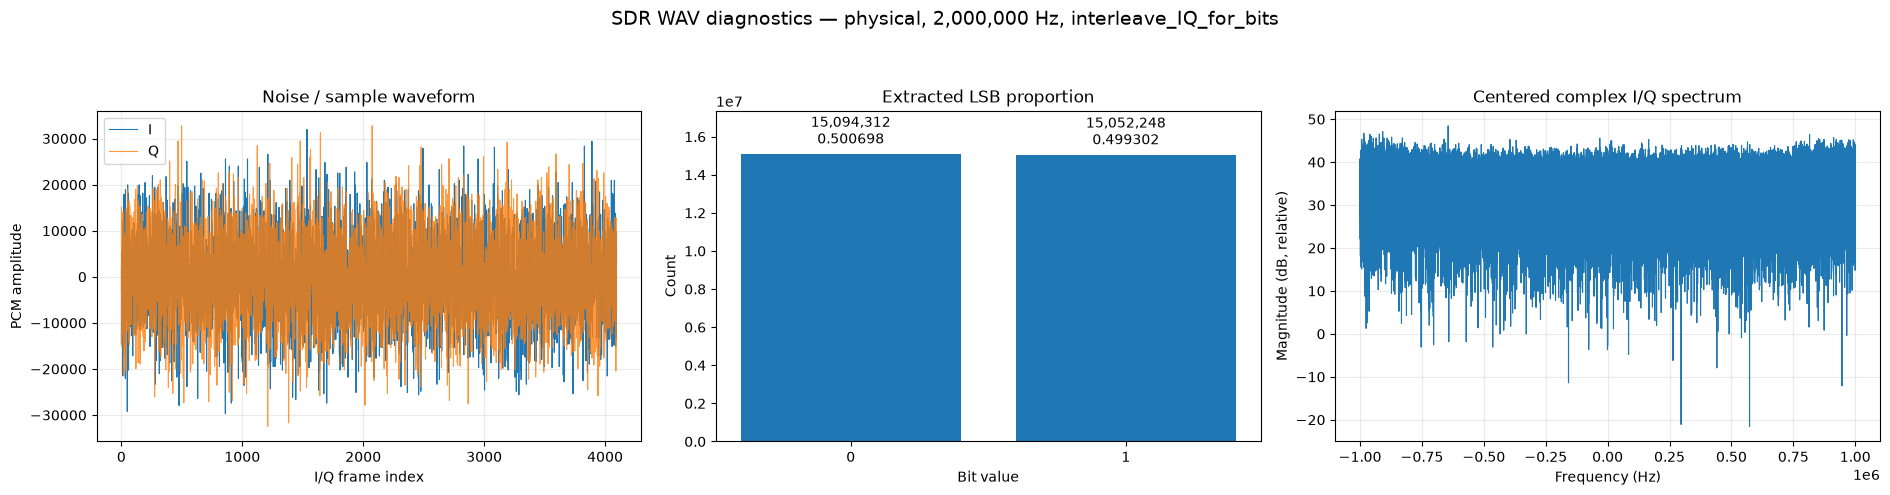

,source,zero_count,one_count,zero_proportion,one_proportion
0,mls,4115897,4118940,0.499815,0.500185
1,python_random,4118364,4116473,0.500115,0.499885
2,pynacl,4115971,4118866,0.499824,0.500176
3,pycryptodome,4117691,4117146,0.500033,0.499967
4,bjt,6683198,6686070,0.499893,0.500107
5,diode,4115682,4119155,0.499789,0.500211
6,sdr,15094312,15052248,0.500698,0.499302


In [17]:
for old_figure in SOURCE_FIGURE_ROOT.glob("*.png"):
    old_figure.unlink()

bit_histogram_records = []

for source, entry in loaded_sources.items():
    samples = entry["samples"]
    bits = raw_bitstreams[source]
    iq_samples = entry["iq_samples"]

    zero_count = int(np.count_nonzero(bits == 0))
    one_count = int(np.count_nonzero(bits == 1))
    counts = [zero_count, one_count]

    zero_proportion = zero_count / len(bits)
    one_proportion = one_count / len(bits)

    bit_histogram_records.append(
        {
            "source": source,
            "zero_count": zero_count,
            "one_count": one_count,
            "zero_proportion": zero_proportion,
            "one_proportion": one_proportion,
        }
    )

    fig, axes = plt.subplots(1, 3, figsize=(19, 5))

    if iq_samples is not None:
        frame_count = min(WAVEFORM_SAMPLES, len(iq_samples))
        frame_indices = np.arange(frame_count)

        axes[0].plot(
            frame_indices,
            iq_samples[:frame_count, 0],
            linewidth=0.8,
            label="I",
        )
        axes[0].plot(
            frame_indices,
            iq_samples[:frame_count, 1],
            linewidth=0.8,
            alpha=0.8,
            label="Q",
        )
        axes[0].set_xlabel("I/Q frame index")
        axes[0].legend()
    else:
        waveform_count = min(WAVEFORM_SAMPLES, len(samples))

        axes[0].plot(
            np.arange(waveform_count),
            samples[:waveform_count],
            linewidth=0.8,
        )
        axes[0].set_xlabel("Sample index")

    axes[0].set_title("Noise / sample waveform")
    axes[0].set_ylabel("PCM amplitude")
    axes[0].grid(alpha=0.25)

    axes[1].bar(["0", "1"], counts)
    axes[1].set_title("Extracted LSB proportion")
    axes[1].set_xlabel("Bit value")
    axes[1].set_ylabel("Count")

    maximum_count = max(counts)
    offset = maximum_count * 0.02 if maximum_count else 1.0

    for position, (count, proportion) in enumerate(
        zip(
            counts,
            [zero_proportion, one_proportion],
        )
    ):
        axes[1].text(
            position,
            count + offset,
            f"{count:,}\n{proportion:.6f}",
            ha="center",
            va="bottom",
        )

    axes[1].set_ylim(
        0,
        maximum_count * 1.15 if maximum_count else 1.0,
    )

    if iq_samples is not None:
        frequencies, magnitude_db = compute_iq_spectrum(
            iq_samples,
            entry["sample_rate"],
        )
        spectrum_title = "Centered complex I/Q spectrum"
    else:
        frequencies, magnitude_db = compute_real_spectrum(
            samples,
            entry["sample_rate"],
        )
        spectrum_title = "One-sided frequency spectrum"

    axes[2].plot(
        frequencies,
        magnitude_db,
        linewidth=0.8,
    )
    axes[2].set_title(spectrum_title)
    axes[2].set_xlabel("Frequency (Hz)")
    axes[2].set_ylabel("Magnitude (dB, relative)")
    axes[2].grid(alpha=0.25)

    fig.suptitle(
        (
            f"{source.upper()} WAV diagnostics — "
            f"{entry['category']}, "
            f"{entry['sample_rate']:,} Hz, "
            f"{entry['channel_policy']}"
        ),
        fontsize=14,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.92])

    figure_path = (
        SOURCE_FIGURE_ROOT
        / f"{source}_combined_diagnostics.png"
    )

    fig.savefig(
        figure_path,
        dpi=250,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

bit_histogram_table = pd.DataFrame(bit_histogram_records)

bit_histogram_table.to_csv(
    RESULTS_ROOT / "raw_bit_histograms.csv",
    index=False,
)

bit_histogram_table


# 10. Common raw window and transformations

The shortest raw bitstream determines the common raw input length.

Every source is cropped to that same prefix **before** raw, Von Neumann, and
XOR variants are constructed. This ensures that a longer recording cannot
contribute more source material than a shorter recording.


# 10. Transformations

## Von Neumann debiasing

Pairs are processed independently:

| Pair | Output |
|---|---|
| `01` | `0` |
| `10` | `1` |
| `00` | discarded |
| `11` | discarded |

Under independent identically distributed input bits, this removes first-order
bias. It does not guarantee independence and can perform poorly when the input
contains temporal correlation.

For balanced independent input, the expected retention is approximately 25%.

## Circular lag-1 XOR

The output is:

\[
y_i = x_i \oplus x_{(i-1)\bmod N}
\]

Circular indexing preserves length. XOR can reduce some forms of bias or
slowly varying structure, but it can also transform correlations rather than
eliminate them. Its effect must be evaluated empirically.


In [18]:
def von_neumann(bits: np.ndarray) -> np.ndarray:
    bits = validate_bits(bits)

    usable_length = len(bits) - (len(bits) % 2)
    pairs = bits[:usable_length].reshape(-1, 2)
    valid = pairs[:, 0] != pairs[:, 1]

    return pairs[valid, 0].astype(
        np.uint8,
        copy=False,
    )


def xor_whiten(
    bits: np.ndarray,
    lag: int = 1,
    *,
    circular: bool = True,
) -> np.ndarray:
    """
    Lagged XOR whitening.

    circular=True preserves input length:
        y[i] = x[i] XOR x[(i-lag) mod N]

    This permits raw and XOR to use the same number of complete sequences.
    """
    bits = validate_bits(bits)

    if lag <= 0 or lag >= len(bits):
        raise ValueError(
            "lag must be positive and smaller than the input."
        )

    if circular:
        return np.bitwise_xor(
            bits,
            np.roll(bits, lag),
        ).astype(np.uint8, copy=False)

    return np.bitwise_xor(
        bits[lag:],
        bits[:-lag],
    ).astype(np.uint8, copy=False)


## Common raw input window

Before any transformation is applied, every source is cropped to the shortest
available raw bit length.

This makes the comparison conservative and fair: a longer recording cannot
gain an advantage merely by contributing more source material.


In [19]:
COMMON_RAW_INPUT_BITS = min(
    len(bits)
    for bits in raw_bitstreams.values()
)

if COMMON_RAW_INPUT_BITS <= XOR_LAG:
    raise RuntimeError(
        "The common raw input is too short for the configured XOR lag."
    )

common_raw_inputs = {
    source: bits[:COMMON_RAW_INPUT_BITS].copy()
    for source, bits in raw_bitstreams.items()
}

raw_input_summary = pd.DataFrame(
    [
        {
            "source": source,
            "available_raw_values": len(raw_bitstreams[source]),
            "common_raw_values_used": COMMON_RAW_INPUT_BITS,
            "raw_values_discarded": (
                len(raw_bitstreams[source])
                - COMMON_RAW_INPUT_BITS
            ),
        }
        for source in sorted(raw_bitstreams)
    ]
)

display(raw_input_summary)

all_variants_untrimmed = {}
transformation_records = []

for source, common_raw_bits in common_raw_inputs.items():
    source_variants = {
        "raw": common_raw_bits.copy(),
        "vn": von_neumann(common_raw_bits),
        "xor": xor_whiten(
            common_raw_bits,
            XOR_LAG,
            circular=True,
        ),
    }

    for transform, output_bits in source_variants.items():
        variant = f"{source}_{transform}"
        output_bits = validate_bits(output_bits, variant)

        all_variants_untrimmed[variant] = output_bits

        transformation_records.append(
            {
                "variant": variant,
                "source": source,
                "transform": transform,
                "common_raw_input_values": COMMON_RAW_INPUT_BITS,
                "untrimmed_output_bits": len(output_bits),
                "retention_ratio": (
                    len(output_bits) / COMMON_RAW_INPUT_BITS
                ),
                "zero_proportion": float(
                    np.mean(output_bits == 0)
                ),
                "one_proportion": float(
                    np.mean(output_bits == 1)
                ),
            }
        )

transformation_summary = pd.DataFrame(
    transformation_records
)

if len(all_variants_untrimmed) != 21:
    raise RuntimeError(
        f"Expected 21 variants, found "
        f"{len(all_variants_untrimmed)}."
    )

common_available_by_transform = (
    transformation_summary
    .groupby("transform")["untrimmed_output_bits"]
    .min()
    .rename("common_available_bits")
)

display(common_available_by_transform)
display(
    transformation_summary.sort_values(
        ["transform", "source"]
    )
)


,source,available_raw_values,common_raw_values_used,raw_values_discarded
0,bjt,13369268,8234837,5134431
1,diode,8234837,8234837,0
2,mls,8234837,8234837,0
3,pycryptodome,8234837,8234837,0
4,pynacl,8234837,8234837,0
5,python_random,8234837,8234837,0
6,sdr,30146560,8234837,21911723


transform
raw    8234837
vn     2056683
xor    8234837
Name: common_available_bits, dtype: int64

,variant,source,transform,common_raw_input_values,untrimmed_output_bits,retention_ratio,zero_proportion,one_proportion
12,bjt_raw,bjt,raw,8234837,8234837,1.000000,0.499902,0.500098
15,diode_raw,diode,raw,8234837,8234837,1.000000,0.499789,0.500211
0,mls_raw,mls,raw,8234837,8234837,1.000000,0.499815,0.500185
9,pycryptodome_raw,pycryptodome,raw,8234837,8234837,1.000000,0.500033,0.499967
6,pynacl_raw,pynacl,raw,8234837,8234837,1.000000,0.499824,0.500176
3,python_random_raw,python_random,raw,8234837,8234837,1.000000,0.500115,0.499885
18,sdr_raw,sdr,raw,8234837,8234837,1.000000,0.500628,0.499372
13,bjt_vn,bjt,vn,8234837,2060058,0.250164,0.500650,0.499350
16,diode_vn,diode,vn,8234837,2059389,0.250083,0.499629,0.500371
1,mls_vn,mls,vn,8234837,2058568,0.249983,0.499761,0.500239


## Family-specific batching policy

Raw, Von Neumann, and XOR are allowed to use different sequence counts because
their output lengths differ substantially.

Within each family, however, all seven sources use exactly the same number of
bits.

The notebook reports:

- available complete sequences;
- requested sequences;
- sequences actually used;
- target shortfall;
- final bits per variant.

The Von Neumann requirement estimate uses the weakest observed retention ratio,
which provides a conservative approximation of how much additional raw data
would be required to reach 55 sequences.


In [20]:
TRANSFORM_ORDER = ("raw", "vn", "xor")

common_available_by_transform = (
    transformation_summary
    .groupby("transform")["untrimmed_output_bits"]
    .min()
    .reindex(TRANSFORM_ORDER)
    .astype(int)
)

available_sequence_count_by_transform = (
    common_available_by_transform
    // NIST_SEQUENCE_BITS
).astype(int)

requested_sequence_count_by_transform = pd.Series(
    {
        "raw": TARGET_RAW_SEQUENCE_COUNT,
        "vn": TARGET_VN_SEQUENCE_COUNT,
        "xor": TARGET_XOR_SEQUENCE_COUNT,
    },
    dtype=int,
)

sequence_count_by_transform = pd.Series(
    {
        transform: min(
            int(available_sequence_count_by_transform.loc[transform]),
            int(requested_sequence_count_by_transform.loc[transform]),
        )
        for transform in TRANSFORM_ORDER
    },
    dtype=int,
)

if (sequence_count_by_transform < 1).any():
    raise RuntimeError(
        "At least one transformation family has fewer than one complete "
        f"{NIST_SEQUENCE_BITS:,}-bit sequence."
    )

target_shortfalls = (
    requested_sequence_count_by_transform
    - available_sequence_count_by_transform
).clip(lower=0)

if STRICT_TARGET_COUNTS and (target_shortfalls > 0).any():
    raise RuntimeError(
        "The requested sequence targets cannot be met:\n"
        + target_shortfalls[target_shortfalls > 0].to_string()
    )

analysis_bits_by_transform = (
    sequence_count_by_transform
    * NIST_SEQUENCE_BITS
).astype(int)

fixed_size_datasets = {}

for row in transformation_summary.itertuples(index=False):
    final_bits = int(
        analysis_bits_by_transform.loc[row.transform]
    )

    fixed_size_datasets[row.variant] = (
        all_variants_untrimmed[row.variant][:final_bits].copy()
    )

transformation_summary["common_available_bits"] = (
    transformation_summary["transform"].map(
        common_available_by_transform
    )
)
transformation_summary["available_sequence_count"] = (
    transformation_summary["transform"].map(
        available_sequence_count_by_transform
    )
)
transformation_summary["requested_sequence_count"] = (
    transformation_summary["transform"].map(
        requested_sequence_count_by_transform
    )
)
transformation_summary["nist_sequence_count"] = (
    transformation_summary["transform"].map(
        sequence_count_by_transform
    )
)
transformation_summary["common_final_bits"] = (
    transformation_summary["transform"].map(
        analysis_bits_by_transform
    )
)
transformation_summary["discarded_after_transform"] = (
    transformation_summary["untrimmed_output_bits"]
    - transformation_summary["common_final_bits"]
)

# Estimate the raw input needed for the requested VN count from the
# weakest observed Von Neumann retention ratio.
vn_rows = transformation_summary.loc[
    transformation_summary["transform"] == "vn"
].copy()

minimum_observed_vn_retention = float(
    vn_rows["retention_ratio"].min()
)

required_vn_output_bits = (
    TARGET_VN_SEQUENCE_COUNT
    * NIST_SEQUENCE_BITS
)

estimated_raw_values_for_target_vn = math.ceil(
    required_vn_output_bits
    / minimum_observed_vn_retention
)

vn_requirement_summary = pd.Series(
    {
        "target_vn_sequences": TARGET_VN_SEQUENCE_COUNT,
        "bits_per_sequence": NIST_SEQUENCE_BITS,
        "required_vn_output_bits": required_vn_output_bits,
        "minimum_observed_vn_retention": (
            minimum_observed_vn_retention
        ),
        "estimated_raw_values_per_source_needed": (
            estimated_raw_values_for_target_vn
        ),
        "current_common_raw_values": COMMON_RAW_INPUT_BITS,
        "additional_raw_values_estimated": max(
            0,
            estimated_raw_values_for_target_vn
            - COMMON_RAW_INPUT_BITS,
        ),
    },
    name="value",
)

batching_summary = pd.DataFrame(
    {
        "transform": TRANSFORM_ORDER,
        "common_available_bits": [
            int(common_available_by_transform.loc[t])
            for t in TRANSFORM_ORDER
        ],
        "available_sequences": [
            int(available_sequence_count_by_transform.loc[t])
            for t in TRANSFORM_ORDER
        ],
        "requested_sequences": [
            int(requested_sequence_count_by_transform.loc[t])
            for t in TRANSFORM_ORDER
        ],
        "used_sequences": [
            int(sequence_count_by_transform.loc[t])
            for t in TRANSFORM_ORDER
        ],
        "target_shortfall": [
            int(target_shortfalls.loc[t])
            for t in TRANSFORM_ORDER
        ],
        "final_bits_per_variant": [
            int(analysis_bits_by_transform.loc[t])
            for t in TRANSFORM_ORDER
        ],
    }
)

transformation_summary.to_csv(
    RESULTS_ROOT / "transformation_summary.csv",
    index=False,
)
batching_summary.to_csv(
    RESULTS_ROOT / "batching_summary_by_transform.csv",
    index=False,
)
vn_requirement_summary.to_csv(
    RESULTS_ROOT / "vn_sequence_requirement_summary.csv",
    header=True,
)

display(batching_summary)
display(vn_requirement_summary)

if int(target_shortfalls.loc["xor"]) > 0:
    print(
        "XOR could not reach 10 sequences because the common raw input "
        "contains fewer than 10,000,000 values."
    )
else:
    print("XOR uses 10 complete sequences.")

if int(target_shortfalls.loc["vn"]) > 0:
    print(
        f"Von Neumann currently provides "
        f"{int(sequence_count_by_transform.loc['vn'])} sequences. "
        f"Approximately {estimated_raw_values_for_target_vn:,} common raw "
        "values per source are estimated to reach 55 sequences at the "
        "weakest observed retention rate."
    )


,transform,common_available_bits,available_sequences,requested_sequences,used_sequences,target_shortfall,final_bits_per_variant
0,raw,8234837,8,10,8,2,8000000
1,vn,2056683,2,55,2,53,2000000
2,xor,8234837,8,10,8,2,8000000


target_vn_sequences                       5.500000e+01
bits_per_sequence                         1.000000e+06
required_vn_output_bits                   5.500000e+07
minimum_observed_vn_retention             2.497539e-01
estimated_raw_values_per_source_needed    2.202167e+08
current_common_raw_values                 8.234837e+06
additional_raw_values_estimated           2.119819e+08
Name: value, dtype: float64

XOR could not reach 10 sequences because the common raw input contains fewer than 10,000,000 values.
Von Neumann currently provides 2 sequences. Approximately 220,216,745 common raw values per source are estimated to reach 55 sequences at the weakest observed retention rate.


# 11. Final common datasets

All 21 variants now contain exactly:

\[
\text{maximum common sequence count}
\times
\text{NIST sequence size}
\]

bits.

The Von Neumann variant with the least output determines the upper bound when
Von Neumann is the shortest transformation, as is normally expected.


In [21]:
if len(fixed_size_datasets) != 21:
    raise RuntimeError(
        f"Expected 21 final datasets, found {len(fixed_size_datasets)}."
    )

for transform in TRANSFORM_ORDER:
    expected_bits = int(
        analysis_bits_by_transform.loc[transform]
    )

    lengths = {
        len(bits)
        for variant, bits in fixed_size_datasets.items()
        if variant.endswith(f"_{transform}")
    }

    if lengths != {expected_bits}:
        raise RuntimeError(
            f"{transform} variants do not all have the same length."
        )

print("Final sequence counts:")
for transform in TRANSFORM_ORDER:
    print(
        f"  {transform:<3}: "
        f"{int(sequence_count_by_transform.loc[transform]):,} sequences "
        f"({int(analysis_bits_by_transform.loc[transform]):,} bits)"
    )

assert len({
    len(bits)
    for name, bits in fixed_size_datasets.items()
    if name.endswith("_vn")
}) == 1


Final sequence counts:
  raw: 8 sequences (8,000,000 bits)
  vn : 2 sequences (2,000,000 bits)
  xor: 8 sequences (8,000,000 bits)


# 11. Export format

Two formats are written for each variant.

### Binary `.bin`

Bits are packed eight at a time, most-significant bit first. This format is
compact and useful for external tools.

### ASCII `.txt`

Each NIST sequence is written as one line containing only `0` and `1`.
This is the format used by the automated NIST runner.

The export functions verify expected lengths before writing, preventing
silently truncated or malformed test inputs.


In [22]:
def save_binary_file(
    path: Path,
    bits: np.ndarray,
    expected_bits: int,
) -> None:
    bits = validate_bits(bits, path.stem)

    if len(bits) != expected_bits:
        raise ValueError(
            f"{path.name} has {len(bits):,} bits; expected "
            f"{expected_bits:,}."
        )

    packed = np.packbits(bits, bitorder="big")

    if len(packed) != expected_bits // 8:
        raise RuntimeError(
            f"{path.name}: incorrect packed length."
        )

    path.write_bytes(packed.tobytes())


def save_ascii_file(
    path: Path,
    bits: np.ndarray,
    sequence_count: int,
) -> None:
    bits = validate_bits(bits, path.stem)

    expected_bits = sequence_count * NIST_SEQUENCE_BITS

    if len(bits) != expected_bits:
        raise ValueError(
            f"{path.name} has {len(bits):,} bits; expected "
            f"{expected_bits:,}."
        )

    sequences = bits.reshape(
        sequence_count,
        NIST_SEQUENCE_BITS,
    )

    with path.open("wb") as output_file:
        for sequence in sequences:
            output_file.write(
                (
                    sequence + np.uint8(ord("0"))
                ).astype(np.uint8, copy=False).tobytes()
            )
            output_file.write(b"\n")


In [23]:
nist_input_records = []

for variant, bits in fixed_size_datasets.items():
    source, transform = variant.rsplit("_", 1)

    sequence_count = int(
        sequence_count_by_transform.loc[transform]
    )
    total_bits = int(
        analysis_bits_by_transform.loc[transform]
    )

    binary_path = NIST_INPUT_ROOT / f"{variant}.bin"
    ascii_path = NIST_INPUT_ROOT / f"{variant}.txt"

    save_binary_file(
        binary_path,
        bits,
        expected_bits=total_bits,
    )
    save_ascii_file(
        ascii_path,
        bits,
        sequence_count=sequence_count,
    )

    nist_input_records.append(
        {
            "variant": variant,
            "source": source,
            "transform": transform,
            "total_bits": total_bits,
            "sequence_bits": NIST_SEQUENCE_BITS,
            "sequence_count": sequence_count,
            "binary_path": str(
                binary_path.relative_to(PROJECT_ROOT)
            ),
            "ascii_path": str(
                ascii_path.relative_to(PROJECT_ROOT)
            ),
            "binary_sha256": sha256_file(binary_path),
            "ascii_sha256": sha256_file(ascii_path),
        }
    )

nist_input_manifest = pd.DataFrame(nist_input_records)

nist_input_manifest.to_csv(
    RESULTS_ROOT / "nist_input_manifest.csv",
    index=False,
)

display(
    nist_input_manifest.sort_values(
        ["transform", "source"]
    )
)


,variant,source,transform,total_bits,sequence_bits,sequence_count,binary_path,ascii_path,binary_sha256,ascii_sha256
12,bjt_raw,bjt,raw,8000000,1000000,8,data/nist_input/bjt_raw.bin,data/nist_input/bjt_raw.txt,80895d8253a99a9497d25dde39cb4acc13a8ed236bb1d8...,45d5187fb090ee36e8224323c26680a61a87c7ed818eb1...
15,diode_raw,diode,raw,8000000,1000000,8,data/nist_input/diode_raw.bin,data/nist_input/diode_raw.txt,d9a476079aa75725607060cb5ac9be610c9340f12a65ad...,625f69475375341f10f8408466b47c309339b607ea1e9c...
0,mls_raw,mls,raw,8000000,1000000,8,data/nist_input/mls_raw.bin,data/nist_input/mls_raw.txt,79b441921cb056468428c8b3b0c932882f1dcc6beb2e4d...,92b3177f466a081e3c47f5a9b47b72701db8f00e0616b5...
9,pycryptodome_raw,pycryptodome,raw,8000000,1000000,8,data/nist_input/pycryptodome_raw.bin,data/nist_input/pycryptodome_raw.txt,1afeabf43fcfe90454b40f2c6e243feff871b6f2583de8...,7cd5a45f39faf84b7c4095c45282985017bb18662bf4cf...
6,pynacl_raw,pynacl,raw,8000000,1000000,8,data/nist_input/pynacl_raw.bin,data/nist_input/pynacl_raw.txt,b8cbf7d6ccb0e077bc01617979c5a1b5f5f10894dfce3e...,d25ef071d9b74662a7da1b1dfeca9548eaf8e459c6c115...
3,python_random_raw,python_random,raw,8000000,1000000,8,data/nist_input/python_random_raw.bin,data/nist_input/python_random_raw.txt,8b27fa10af53fb67cf349699d4d2dbcb1e3df2284012b4...,fb7b03c36dfc95fb6dc726c02d267752a4bb3e0226c9a2...
18,sdr_raw,sdr,raw,8000000,1000000,8,data/nist_input/sdr_raw.bin,data/nist_input/sdr_raw.txt,43418af5529cc809e4614cccd0d3abab6ec9b0c22b17e5...,a231bf2b30470cf60d55523b0f6f9047a6ee0f342e94cb...
13,bjt_vn,bjt,vn,2000000,1000000,2,data/nist_input/bjt_vn.bin,data/nist_input/bjt_vn.txt,0c781e07282dd4d55561ce3a7b5413e066656badc284a0...,e8ccc434ac4c82c0bb396aee4a4448ae20c07b48a2f2f9...
16,diode_vn,diode,vn,2000000,1000000,2,data/nist_input/diode_vn.bin,data/nist_input/diode_vn.txt,2697ecb0412a6d2ca6cf8d894223eb617d8e38519622ea...,d35b6722c1209dda71fbefc4ea6d8b28086ee8b901980a...
1,mls_vn,mls,vn,2000000,1000000,2,data/nist_input/mls_vn.bin,data/nist_input/mls_vn.txt,184c555635ceee194f589e81b29edeedf8b4fec18211e9...,0e54af7795ef8930f351eae76c8bc921d72ff93c46df67...


## Independent export verification

The notebook reopens every exported file and verifies:

- expected byte count;
- expected sequence count;
- exactly 1,000,000 bits per sequence;
- absence of characters other than `0` and `1`.

This separates file-generation logic from file-verification logic and makes
corruption or formatting mistakes easier to detect.


In [24]:
verification_records = []

for row in nist_input_manifest.itertuples(index=False):
    binary_path = PROJECT_ROOT / row.binary_path
    ascii_path = PROJECT_ROOT / row.ascii_path

    expected_binary_bytes = row.total_bits // 8
    expected_ascii_bytes = row.total_bits + row.sequence_count

    if binary_path.stat().st_size != expected_binary_bytes:
        raise RuntimeError(
            f"Incorrect binary size: {binary_path}"
        )

    if ascii_path.stat().st_size != expected_ascii_bytes:
        raise RuntimeError(
            f"Incorrect ASCII size: {ascii_path}"
        )

    with ascii_path.open("rb") as input_file:
        lines = [line.rstrip(b"\n") for line in input_file]

    if len(lines) != row.sequence_count:
        raise RuntimeError(
            f"Incorrect sequence count: {ascii_path}"
        )

    if any(len(line) != NIST_SEQUENCE_BITS for line in lines):
        raise RuntimeError(
            f"Incorrect sequence length: {ascii_path}"
        )

    if any(set(line) - {ord("0"), ord("1")} for line in lines):
        raise RuntimeError(
            f"Non-binary characters found: {ascii_path}"
        )

    verification_records.append(
        {
            "variant": row.variant,
            "transform": row.transform,
            "sequence_count": row.sequence_count,
            "valid": True,
        }
    )

export_verification = pd.DataFrame(
    verification_records
)

export_verification.to_csv(
    RESULTS_ROOT / "nist_input_verification.csv",
    index=False,
)

display(
    export_verification.groupby("transform")[
        "sequence_count"
    ].agg(["min", "max"])
)


,min,max
transform,,
raw,8,8
vn,2,2
xor,8,8


# 14. NIST STS readiness and statistical interpretation

## Why sequences are grouped into batches

NIST STS operates on a collection of fixed-length bitstreams. Here, one
sequence contains 1,000,000 bits.

The notebook selects sequence counts independently by transformation family:

- raw: up to 10 equal sequences per source;
- XOR: up to 10 equal sequences per source;
- Von Neumann: one equal count across all sources, targeting 55 when possible.

The choice of 55 for the Von Neumann target is motivated by the second-level
uniformity calculation. NIST divides first-level p-values into ten bins.
Very small sequence counts make that distribution too sparse to interpret
reliably.

## What the two reported measures mean

### Pass proportion

For a given test, this is the fraction of eligible sequences whose p-value is
at least the selected significance level. A low pass proportion suggests that
the source or transformation is inconsistent with the test's null model.

### Uniformity p-value

This measures whether the collection of first-level p-values is reasonably
uniform over the interval from zero to one. It is a property of a group of
sequences, not of one individual sequence.

## Important exception: Random Excursions

`RandomExcursions` and `RandomExcursionsVariant` require enough cycles in the
cumulative random walk. A cell can therefore be `N/A` even when the source has
many input sequences. In that case, the result is **not applicable**, not an
automatic failure.


# 15. Automated NIST STS execution

The NIST executable requires an absolute input path internally. That path is
never displayed or stored in user-facing metadata.

The standard response stream is conceptually:

```text
use a user-supplied file
select the input file
apply all tests
retain default test parameters
enter the sequence count
select ASCII input
```

A run is accepted only when:

1. the completion marker appears in captured process output;
2. a fresh, nonempty `finalAnalysisReport.txt` exists;
3. the result directory is copied into `results/nist/<variant>/`;
4. the archived report hash is recorded.

The program's process return code is stored for reproducibility but is not used
alone to classify success because some NIST STS builds return a nonzero code
after a successful run.


In [25]:
def build_nist_stdin(
    input_path: Path,
    sequence_count: int,
) -> str:
    """
    Build the interactive input stream required by NIST STS.

    The external executable receives an absolute path, but that path is not
    returned, displayed, or stored in notebook metadata.
    """
    resolved_input = input_path.resolve()

    if not resolved_input.is_file():
        raise FileNotFoundError(
            "NIST input file does not exist: "
            f"{relative_project_path(input_path)}"
        )

    if sequence_count <= 0:
        raise ValueError("sequence_count must be positive.")

    responses = [
        "0",
        str(resolved_input),
        "1",
        "0",
        str(sequence_count),
        "0",
    ]

    return "\n".join(responses) + "\n"


def clear_nist_working_results() -> None:
    """
    Delete mutable NIST result files while preserving the directory tree.
    """
    if not NIST_WORKING_RESULTS.is_dir():
        raise FileNotFoundError(
            "NIST working directory not found: "
            f"{relative_project_path(NIST_WORKING_RESULTS)}"
        )

    for path in NIST_WORKING_RESULTS.rglob("*"):
        if path.is_file():
            path.unlink()


In [26]:
def existing_nist_result_matches(
    destination: Path,
    input_path: Path,
    sequence_count: int,
) -> bool:
    """
    Reuse an archived result only when its input and configuration match.
    """
    report_path = destination / "finalAnalysisReport.txt"
    metadata_path = destination / "run_metadata.json"

    if (
        not report_path.is_file()
        or report_path.stat().st_size == 0
        or not metadata_path.is_file()
    ):
        return False

    try:
        metadata = json.loads(
            metadata_path.read_text(encoding="utf-8")
        )
    except Exception:
        return False

    return (
        metadata.get("input_sha256") == sha256_file(input_path)
        and metadata.get("sequence_bits") == NIST_SEQUENCE_BITS
        and metadata.get("sequence_count") == sequence_count
        and metadata.get("report_sha256") == sha256_file(report_path)
    )


def run_nist_variant(
    variant: str,
    input_path: Path,
    sequence_count: int,
    overwrite: bool = False,
) -> dict:
    """
    Execute NIST STS for one source/transformation variant.

    Captured logs are sanitized before they are written to disk.
    """
    resolved_input = input_path.resolve()
    destination = NIST_RESULTS_ROOT / variant

    if (
        not overwrite
        and existing_nist_result_matches(
            destination,
            resolved_input,
            sequence_count,
        )
    ):
        return {
            "variant": variant,
            "status": "skipped_matching_existing",
            "sequence_count": sequence_count,
            "input_path": relative_project_path(resolved_input),
            "result_directory": relative_project_path(destination),
        }

    if destination.exists():
        shutil.rmtree(destination)

    clear_nist_working_results()

    completed = subprocess.run(
        [
            str(NIST_ASSESS.resolve()),
            str(NIST_SEQUENCE_BITS),
        ],
        input=build_nist_stdin(
            resolved_input,
            sequence_count,
        ),
        text=True,
        cwd=NIST_STS_ROOT,
        capture_output=True,
        timeout=NIST_TIMEOUT_SECONDS,
        check=False,
    )

    sanitized_stdout = redact_local_paths(completed.stdout)
    sanitized_stderr = redact_local_paths(completed.stderr)

    stdout_path = NIST_LOG_ROOT / f"{variant}_stdout.log"
    stderr_path = NIST_LOG_ROOT / f"{variant}_stderr.log"

    stdout_path.write_text(
        sanitized_stdout,
        encoding="utf-8",
    )
    stderr_path.write_text(
        sanitized_stderr,
        encoding="utf-8",
    )

    working_report = (
        NIST_WORKING_RESULTS
        / "finalAnalysisReport.txt"
    )

    completion_marker_found = (
        "statistical testing complete"
        in (
            sanitized_stdout
            + "\n"
            + sanitized_stderr
        ).lower()
    )

    report_is_valid = (
        working_report.is_file()
        and working_report.stat().st_size > 0
    )

    if not completion_marker_found or not report_is_valid:
        raise RuntimeError(
            f"NIST STS did not complete for {variant}.\n"
            f"Sequence count: {sequence_count}\n"
            f"Return code: {completed.returncode}\n"
            f"Completion marker found: {completion_marker_found}\n"
            f"Valid report produced: {report_is_valid}\n"
            f"STDOUT tail:\n{sanitized_stdout[-4000:]}\n"
            f"STDERR tail:\n{sanitized_stderr[-4000:]}\n"
            f"Logs: {relative_project_path(stdout_path)}, "
            f"{relative_project_path(stderr_path)}"
        )

    shutil.copytree(
        NIST_WORKING_RESULTS,
        destination,
    )

    copied_report = destination / "finalAnalysisReport.txt"

    if (
        not copied_report.is_file()
        or copied_report.stat().st_size == 0
    ):
        raise RuntimeError(
            f"Archived report is missing for {variant}."
        )

    metadata = {
        "variant": variant,
        "status": "completed",
        "process_return_code": completed.returncode,
        "input_path": relative_project_path(resolved_input),
        "input_sha256": sha256_file(resolved_input),
        "sequence_bits": NIST_SEQUENCE_BITS,
        "sequence_count": sequence_count,
        "total_analysis_bits": (
            sequence_count * NIST_SEQUENCE_BITS
        ),
        "report_path": relative_project_path(copied_report),
        "report_sha256": sha256_file(copied_report),
        "stdout_log": relative_project_path(stdout_path),
        "stderr_log": relative_project_path(stderr_path),
    }

    (destination / "run_metadata.json").write_text(
        json.dumps(metadata, indent=2),
        encoding="utf-8",
    )

    return metadata


In [27]:
nist_run_records = []

if RUN_NIST_STS:
    for row in nist_input_manifest.itertuples(index=False):
        try:
            record = run_nist_variant(
                variant=row.variant,
                input_path=PROJECT_ROOT / row.ascii_path,
                sequence_count=int(row.sequence_count),
                overwrite=OVERWRITE_NIST_RESULTS,
            )
        except Exception as error:
            record = {
                "variant": row.variant,
                "transform": row.transform,
                "sequence_count": row.sequence_count,
                "status": "failed",
                "error": str(error),
            }

        nist_run_records.append(record)

        print(
            f"{row.variant:<24} "
            f"{int(row.sequence_count):>4} sequences  "
            f"{record['status']}"
        )

        if (
            record["status"] == "failed"
            and STOP_ON_NIST_ERROR
        ):
            break

    nist_run_manifest = pd.DataFrame(nist_run_records)

    nist_run_manifest.to_csv(
        RESULTS_ROOT / "nist_run_manifest.csv",
        index=False,
    )

    display(nist_run_manifest)

    if (nist_run_manifest["status"] == "failed").any():
        raise RuntimeError(
            "At least one NIST run failed. Inspect logs/nist."
        )
else:
    print("NIST STS execution is disabled.")


mls_raw                     8 sequences  completed
mls_vn                      2 sequences  completed
mls_xor                     8 sequences  completed
python_random_raw           8 sequences  completed
python_random_vn            2 sequences  completed
python_random_xor           8 sequences  completed
pynacl_raw                  8 sequences  completed
pynacl_vn                   2 sequences  completed
pynacl_xor                  8 sequences  completed
pycryptodome_raw            8 sequences  completed
pycryptodome_vn             2 sequences  completed
pycryptodome_xor            8 sequences  completed
bjt_raw                     8 sequences  completed
bjt_vn                      2 sequences  completed
bjt_xor                     8 sequences  completed
diode_raw                   8 sequences  completed
diode_vn                    2 sequences  completed
diode_xor                   8 sequences  completed
sdr_raw                     8 sequences  completed
sdr_vn                      2 s

,variant,status,process_return_code,input_path,input_sha256,sequence_bits,sequence_count,total_analysis_bits,report_path,report_sha256,stdout_log,stderr_log
0,mls_raw,completed,1,data/nist_input/mls_raw.txt,92b3177f466a081e3c47f5a9b47b72701db8f00e0616b5...,1000000,8,8000000,results/nist/mls_raw/finalAnalysisReport.txt,7f72452f30071e23e9ba92e92bbea38e419968ce579d19...,logs/nist/mls_raw_stdout.log,logs/nist/mls_raw_stderr.log
1,mls_vn,completed,1,data/nist_input/mls_vn.txt,0e54af7795ef8930f351eae76c8bc921d72ff93c46df67...,1000000,2,2000000,results/nist/mls_vn/finalAnalysisReport.txt,0197a53099ed2b60aa814db7299c87d14ef87c0cb5a16c...,logs/nist/mls_vn_stdout.log,logs/nist/mls_vn_stderr.log
2,mls_xor,completed,1,data/nist_input/mls_xor.txt,4920239c8fdd421a1cb218d63a6e0dec0cd9acd1a8cc17...,1000000,8,8000000,results/nist/mls_xor/finalAnalysisReport.txt,d5154dbc5153920aa1d84a5675d3e2e92331580844da03...,logs/nist/mls_xor_stdout.log,logs/nist/mls_xor_stderr.log
3,python_random_raw,completed,1,data/nist_input/python_random_raw.txt,fb7b03c36dfc95fb6dc726c02d267752a4bb3e0226c9a2...,1000000,8,8000000,results/nist/python_random_raw/finalAnalysisRe...,f408a705cedd62e6c56a435911d9e2a5f8703017a5d3bf...,logs/nist/python_random_raw_stdout.log,logs/nist/python_random_raw_stderr.log
4,python_random_vn,completed,1,data/nist_input/python_random_vn.txt,a3a8fe9f4340402a90bd72659c929f9a4e9167af6c2701...,1000000,2,2000000,results/nist/python_random_vn/finalAnalysisRep...,d0dcdc405c379fcbcfa4e84bbcf7ab9ba58e0945abbe37...,logs/nist/python_random_vn_stdout.log,logs/nist/python_random_vn_stderr.log
5,python_random_xor,completed,1,data/nist_input/python_random_xor.txt,53cb88278be79db24b5e95625ace0ac9440ccaed94efa7...,1000000,8,8000000,results/nist/python_random_xor/finalAnalysisRe...,21ff9c24f5116fc4608ac63898d9fbd6a4f497eb4982a6...,logs/nist/python_random_xor_stdout.log,logs/nist/python_random_xor_stderr.log
6,pynacl_raw,completed,1,data/nist_input/pynacl_raw.txt,d25ef071d9b74662a7da1b1dfeca9548eaf8e459c6c115...,1000000,8,8000000,results/nist/pynacl_raw/finalAnalysisReport.txt,91d2f5989bf66d05005df49beaffff58e4f6988878d378...,logs/nist/pynacl_raw_stdout.log,logs/nist/pynacl_raw_stderr.log
7,pynacl_vn,completed,1,data/nist_input/pynacl_vn.txt,1381b5355c6343215faba3be0532189627e29487217911...,1000000,2,2000000,results/nist/pynacl_vn/finalAnalysisReport.txt,bd87d784e896c75641156e99a5f02963ec4845f53822cf...,logs/nist/pynacl_vn_stdout.log,logs/nist/pynacl_vn_stderr.log
8,pynacl_xor,completed,1,data/nist_input/pynacl_xor.txt,28f02465ee661eda4f16c0ba538a7592e9434e52b74686...,1000000,8,8000000,results/nist/pynacl_xor/finalAnalysisReport.txt,cd1df625b76e395a6cefbedfd9c0195038080779f9f806...,logs/nist/pynacl_xor_stdout.log,logs/nist/pynacl_xor_stderr.log
9,pycryptodome_raw,completed,1,data/nist_input/pycryptodome_raw.txt,7cd5a45f39faf84b7c4095c45282985017bb18662bf4cf...,1000000,8,8000000,results/nist/pycryptodome_raw/finalAnalysisRep...,47bf25181bf81f45c9dbe3c4d7773420f1ec1d9c9e02bd...,logs/nist/pycryptodome_raw_stdout.log,logs/nist/pycryptodome_raw_stderr.log


# 16. Report inventory


# 16. Report inventory

NIST writes into one mutable working directory. After each successful run, the
entire result tree is archived under a variant-specific directory.

The inventory checks that all 21 final reports exist and are nonempty before
parsing begins. This prevents partial experiments from being presented as a
complete comparison.


In [28]:
expected_variants = set(
    nist_input_manifest["variant"]
)

report_inventory = pd.DataFrame(
    [
        {
            "variant": variant,
            "report_path": str(
                (
                    NIST_RESULTS_ROOT
                    / variant
                    / "finalAnalysisReport.txt"
                ).relative_to(PROJECT_ROOT)
            ),
            "exists": (
                NIST_RESULTS_ROOT
                / variant
                / "finalAnalysisReport.txt"
            ).is_file(),
            "size_bytes": (
                (
                    NIST_RESULTS_ROOT
                    / variant
                    / "finalAnalysisReport.txt"
                ).stat().st_size
                if (
                    NIST_RESULTS_ROOT
                    / variant
                    / "finalAnalysisReport.txt"
                ).is_file()
                else 0
            ),
        }
        for variant in sorted(expected_variants)
    ]
)

report_inventory["valid"] = (
    report_inventory["exists"]
    & (report_inventory["size_bytes"] > 0)
)

NIST_REPORTS_COMPLETE = bool(
    len(report_inventory) == 21
    and report_inventory["valid"].all()
)

print(
    f"Valid reports: "
    f"{int(report_inventory['valid'].sum())} / "
    f"{len(report_inventory)}"
)
print("Reports complete:", NIST_REPORTS_COMPLETE)

report_inventory


Valid reports: 21 / 21
Reports complete: True


,variant,report_path,exists,size_bytes,valid
0,bjt_raw,results/nist/bjt_raw/finalAnalysisReport.txt,True,17493,True
1,bjt_vn,results/nist/bjt_vn/finalAnalysisReport.txt,True,17492,True
2,bjt_xor,results/nist/bjt_xor/finalAnalysisReport.txt,True,17493,True
3,diode_raw,results/nist/diode_raw/finalAnalysisReport.txt,True,17495,True
4,diode_vn,results/nist/diode_vn/finalAnalysisReport.txt,True,17494,True
5,diode_xor,results/nist/diode_xor/finalAnalysisReport.txt,True,17495,True
6,mls_raw,results/nist/mls_raw/finalAnalysisReport.txt,True,17493,True
7,mls_vn,results/nist/mls_vn/finalAnalysisReport.txt,True,17492,True
8,mls_xor,results/nist/mls_xor/finalAnalysisReport.txt,True,17493,True
9,pycryptodome_raw,results/nist/pycryptodome_raw/finalAnalysisRep...,True,17502,True


# 17. Parse NIST reports

This section runs only after all 21 nonempty reports are available.


# 17. Parsing NIST results

A final NIST report row contains:

- ten p-value histogram-bin counts;
- a uniformity p-value or `----`;
- the number of passing and eligible sequences;
- optional failure markers;
- the test name.

`----` is converted to a missing value because it means the statistic was not
available. It must not be converted to zero, since zero would imply a valid but
extremely poor result.


In [29]:
NIST_TEST_NAMES = [
    "Frequency",
    "BlockFrequency",
    "CumulativeSums",
    "Runs",
    "LongestRun",
    "Rank",
    "FFT",
    "NonOverlappingTemplate",
    "OverlappingTemplate",
    "Universal",
    "ApproximateEntropy",
    "RandomExcursions",
    "RandomExcursionsVariant",
    "Serial",
    "LinearComplexity",
]

NIST_REPORT_ROW_PATTERN = re.compile(
    r"^\s*"
    r"(?P<histogram>(?:\d+\s+){10})"
    r"(?P<uniformity>----|(?:0|1)(?:\.\d+)?)"
    r"\s*(?P<uniformity_flag>\*)?\s+"
    r"(?P<passed>\d+)\s*/\s*(?P<eligible>\d+)"
    r"\s*(?P<proportion_flag>\*)?\s+"
    r"(?P<test>[A-Za-z]+)"
    r"\s*$"
)


def parse_nist_result_line(
    line: str,
) -> dict | None:
    match = NIST_REPORT_ROW_PATTERN.match(line)

    if match is None:
        return None

    histogram = [
        int(value)
        for value in match.group("histogram").split()
    ]

    uniformity_token = match.group("uniformity")
    uniformity = (
        np.nan
        if uniformity_token == "----"
        else float(uniformity_token)
    )

    passed = int(match.group("passed"))
    eligible = int(match.group("eligible"))

    return {
        "histogram": histogram,
        "uniformity_p_value": uniformity,
        "uniformity_flagged": bool(
            match.group("uniformity_flag")
        ),
        "passed": passed,
        "eligible": eligible,
        "pass_proportion": (
            passed / eligible
            if eligible > 0
            else np.nan
        ),
        "proportion_flagged": bool(
            match.group("proportion_flag")
        ),
        "test": match.group("test"),
    }


In [30]:
def parse_report(
    report_path: Path,
    variant: str,
    sequence_count: int,
) -> pd.DataFrame:
    rows = []
    occurrence_counter = {}

    text = report_path.read_text(
        encoding="utf-8",
        errors="replace",
    )

    for line_number, line in enumerate(
        text.splitlines(),
        start=1,
    ):
        parsed = parse_nist_result_line(line)

        if parsed is None:
            continue

        test_name = parsed["test"]

        if test_name not in NIST_TEST_NAMES:
            continue

        occurrence_counter[test_name] = (
            occurrence_counter.get(test_name, 0) + 1
        )

        row = {
            "variant": variant,
            "sequence_count": sequence_count,
            "line_number": line_number,
            "test": test_name,
            "subtest_index": occurrence_counter[test_name],
            "passed": parsed["passed"],
            "eligible": parsed["eligible"],
            "pass_proportion": parsed["pass_proportion"],
            "proportion_flagged": parsed[
                "proportion_flagged"
            ],
            "uniformity_p_value": parsed[
                "uniformity_p_value"
            ],
            "uniformity_flagged": parsed[
                "uniformity_flagged"
            ],
            "raw_line": line,
        }

        for index, count in enumerate(
            parsed["histogram"],
            start=1,
        ):
            row[f"C{index}"] = count

        rows.append(row)

    return pd.DataFrame(rows)


## Aggregating multirow test families

Some NIST families produce multiple report rows:

- Cumulative Sums;
- Serial;
- Non-overlapping Template;
- Random Excursions;
- Random Excursions Variant.

For a compact family-level heatmap, the notebook retains the minimum pass
proportion and minimum available uniformity p-value across the family's rows.

This is a conservative descriptive summary, not an official replacement for
the full row-level report. The complete parsed rows remain available in
`results/nist_results_long.csv`.


In [31]:
if NIST_REPORTS_COMPLETE:
    sequence_count_lookup = (
        nist_input_manifest
        .set_index("variant")["sequence_count"]
        .to_dict()
    )

    parsed_frames = []

    for variant in sorted(expected_variants):
        report_path = (
            NIST_RESULTS_ROOT
            / variant
            / "finalAnalysisReport.txt"
        )

        parsed = parse_report(
            report_path,
            variant,
            sequence_count=int(
                sequence_count_lookup[variant]
            ),
        )

        if parsed.empty:
            raise RuntimeError(
                f"No rows parsed from {report_path}."
            )

        parsed_frames.append(parsed)

    nist_results_long = pd.concat(
        parsed_frames,
        ignore_index=True,
    )

    parts = nist_results_long[
        "variant"
    ].str.rsplit("_", n=1, expand=True)

    nist_results_long["source"] = parts[0]
    nist_results_long["transform"] = parts[1]

    nist_results_long.to_csv(
        RESULTS_ROOT / "nist_results_long.csv",
        index=False,
    )

    nist_results_aggregated = (
        nist_results_long
        .groupby(
            [
                "variant",
                "source",
                "transform",
                "sequence_count",
                "test",
            ],
            as_index=False,
        )
        .agg(
            pass_proportion=("pass_proportion", "min"),
            uniformity_p_value=("uniformity_p_value", "min"),
            eligible_sequences=("eligible", "min"),
            subtest_rows=("test", "size"),
        )
    )

    nist_results_aggregated.to_csv(
        RESULTS_ROOT / "nist_results_aggregated.csv",
        index=False,
    )
else:
    print("NIST report parsing skipped.")


# 18. Cividis heatmaps

The heatmaps are generated only when all NIST reports were parsed.


In [32]:
SOURCE_ORDER = [
    "bjt",
    "diode",
    "sdr",
    "mls",
    "python_random",
    "pynacl",
    "pycryptodome",
]

TRANSFORM_ORDER = ["raw", "vn", "xor"]

VARIANT_ORDER = [
    f"{source}_{transform}"
    for source in SOURCE_ORDER
    for transform in TRANSFORM_ORDER
]

TEST_ORDER = NIST_TEST_NAMES


# 18. Heatmap design

The `cividis` colormap is perceptually ordered and remains interpretable for
many viewers with color-vision deficiencies.

Color meanings:

- values near 1: high pass proportion or high uniformity p-value;
- values near 0: poor result;
- gray `N/A`: the test did not produce an applicable numeric result.

The pass-proportion heatmap may combine families with different sequence
counts. The title records the raw, Von Neumann, and XOR counts explicitly.


In [33]:
def plot_heatmap(
    matrix: pd.DataFrame,
    title: str,
    colorbar_label: str,
    output_path: Path,
) -> None:
    values = matrix.to_numpy(dtype=float)
    masked = np.ma.masked_invalid(values)

    cmap = plt.colormaps["cividis"].copy()
    cmap.set_bad("lightgray")

    figure_width = max(
        14,
        0.9 * len(matrix.columns) + 6,
    )
    figure_height = max(
        8,
        0.36 * len(matrix.index) + 3,
    )

    fig, ax = plt.subplots(
        figsize=(figure_width, figure_height)
    )

    image = ax.imshow(
        masked,
        aspect="auto",
        cmap=cmap,
        vmin=0.0,
        vmax=1.0,
    )

    ax.set_xticks(np.arange(len(matrix.columns)))
    ax.set_xticklabels(
        matrix.columns,
        rotation=90,
    )

    ax.set_yticks(np.arange(len(matrix.index)))
    ax.set_yticklabels(matrix.index)

    ax.set_title(title)
    ax.set_xlabel("NIST statistical test")
    ax.set_ylabel("Source and transform")

    for row_index in range(values.shape[0]):
        for column_index in range(values.shape[1]):
            value = values[row_index, column_index]

            label = (
                f"{value:.2f}"
                if np.isfinite(value)
                else "N/A"
            )

            ax.text(
                column_index,
                row_index,
                label,
                ha="center",
                va="center",
                fontsize=7,
            )

    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label(colorbar_label)

    fig.tight_layout()
    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)


## Reading the final figures

A heatmap should be read by comparing:

1. the same source across raw, Von Neumann, and XOR;
2. the same transformation across all sources;
3. related tests rather than isolated cells;
4. numeric values together with `N/A` eligibility information.

A transformation is not automatically better because it turns more cells
yellow. It may discard data, alter dependence, or mask one defect while
introducing another.

The most defensible interpretation combines:

- transformation retention;
- source diagnostics;
- individual NIST test behavior;
- the number of eligible sequences;
- known properties of each generator.


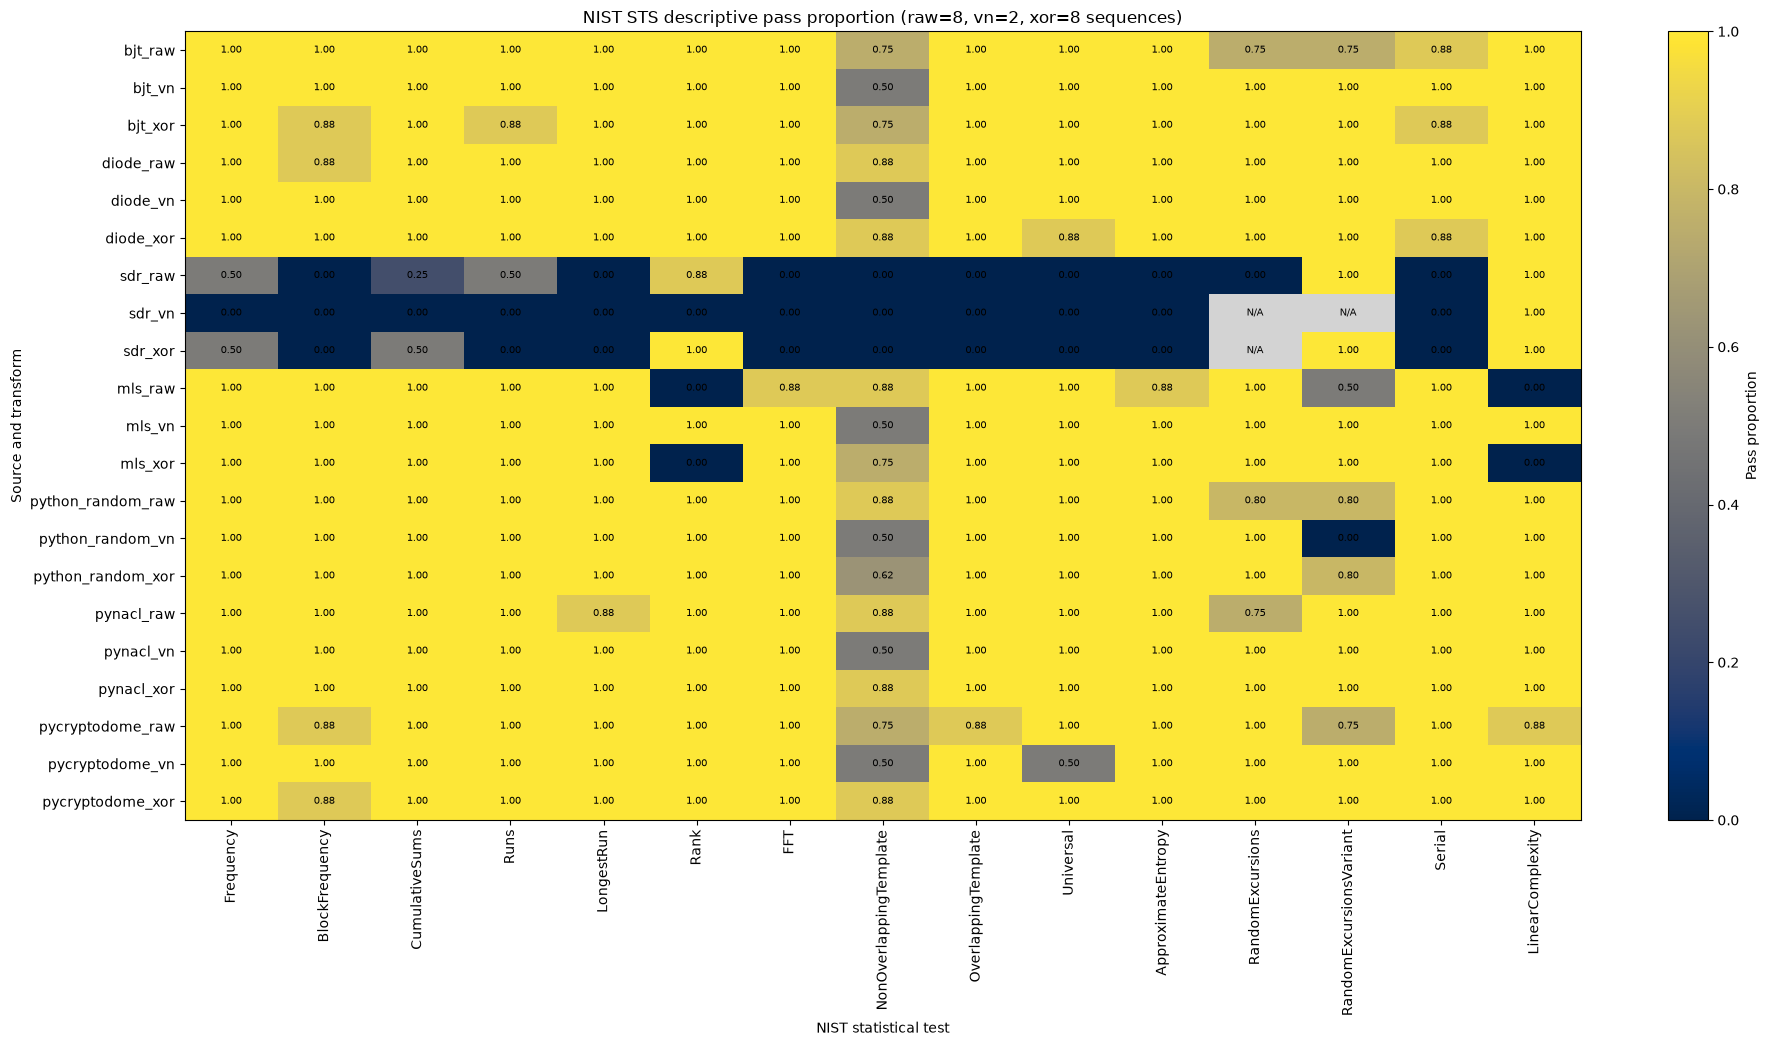

Uniformity heatmap skipped: no eligible transformation family has enough numeric uniformity values.
RandomExcursions tests can still be N/A when too few sequences meet their cycle requirement.


In [34]:
if NIST_REPORTS_COMPLETE:
    pass_matrix = (
        nist_results_aggregated
        .pivot(
            index="variant",
            columns="test",
            values="pass_proportion",
        )
        .reindex(
            index=VARIANT_ORDER,
            columns=TEST_ORDER,
        )
    )

    pass_matrix.to_csv(
        RESULTS_ROOT / "nist_pass_proportion_matrix.csv"
    )

    count_text = ", ".join(
        f"{t}={int(sequence_count_by_transform.loc[t])}"
        for t in TRANSFORM_ORDER
    )

    plot_heatmap(
        pass_matrix,
        f"NIST STS descriptive pass proportion ({count_text} sequences)",
        "Pass proportion",
        (
            FIGURES_ROOT
            / "nist_pass_proportion_heatmap_cividis.png"
        ),
    )

    uniformity_matrix = (
        nist_results_aggregated
        .pivot(
            index="variant",
            columns="test",
            values="uniformity_p_value",
        )
        .reindex(
            index=VARIANT_ORDER,
            columns=TEST_ORDER,
        )
    )

    sequence_count_lookup = (
        nist_input_manifest
        .set_index("variant")["sequence_count"]
    )

    eligible_variants = [
        variant
        for variant in VARIANT_ORDER
        if int(sequence_count_lookup.loc[variant])
        >= MINIMUM_UNIFORMITY_SEQUENCES
    ]

    uniformity_plot_matrix = (
        uniformity_matrix.loc[eligible_variants]
        if eligible_variants
        else pd.DataFrame()
    )

    if (
        not uniformity_plot_matrix.empty
        and uniformity_plot_matrix.notna().any().any()
    ):
        uniformity_plot_matrix.to_csv(
            RESULTS_ROOT
            / "nist_uniformity_p_value_matrix.csv"
        )

        plot_heatmap(
            uniformity_plot_matrix,
            "NIST STS uniformity p-value",
            "Uniformity p-value",
            (
                FIGURES_ROOT
                / "nist_uniformity_p_value_heatmap_cividis.png"
            ),
        )
    else:
        print(
            "Uniformity heatmap skipped: no eligible transformation "
            "family has enough numeric uniformity values."
        )

    print(
        "RandomExcursions tests can still be N/A when too few sequences "
        "meet their cycle requirement."
    )
else:
    print("Heatmap generation skipped.")


In [35]:
if NIST_REPORTS_COMPLETE:
    result_overview = (
        nist_results_aggregated
        .groupby(
            ["source", "transform"],
            as_index=False,
        )
        .agg(
            sequence_count=("sequence_count", "first"),
            tests_reported=("test", "nunique"),
            minimum_pass_proportion=(
                "pass_proportion",
                "min",
            ),
            median_pass_proportion=(
                "pass_proportion",
                "median",
            ),
            unavailable_uniformity_values=(
                "uniformity_p_value",
                lambda values: int(values.isna().sum()),
            ),
        )
        .sort_values(
            ["transform", "source"]
        )
    )

    result_overview.to_csv(
        RESULTS_ROOT / "result_interpretation_overview.csv",
        index=False,
    )

    display(result_overview)

    unavailable_cells = int(
        pass_matrix.isna().sum().sum()
    )

    zero_pass_cells = int(
        (pass_matrix == 0.0).sum().sum()
    )

    full_pass_cells = int(
        (pass_matrix == 1.0).sum().sum()
    )

    display(
        Markdown(
            "### Automatically generated result notes\n\n"
            f"- Pass-proportion cells with numeric value `1.00`: "
            f"**{full_pass_cells}**\n"
            f"- Pass-proportion cells with numeric value `0.00`: "
            f"**{zero_pass_cells}**\n"
            f"- Pass-proportion cells marked `N/A`: "
            f"**{unavailable_cells}**\n\n"
            "`N/A` cells indicate missing eligibility or unavailable "
            "second-level statistics. They are not counted as failures."
        )
    )
else:
    print(
        "Automatic result interpretation is unavailable until all "
        "NIST reports have been generated and parsed."
    )


,source,transform,sequence_count,tests_reported,minimum_pass_proportion,median_pass_proportion,unavailable_uniformity_values
0,bjt,raw,8,15,0.750,1.0,15
3,diode,raw,8,15,0.875,1.0,15
6,mls,raw,8,15,0.000,1.0,15
9,pycryptodome,raw,8,15,0.750,1.0,15
12,pynacl,raw,8,15,0.750,1.0,15
15,python_random,raw,8,15,0.800,1.0,15
18,sdr,raw,8,15,0.000,0.0,15
1,bjt,vn,2,15,0.500,1.0,15
4,diode,vn,2,15,0.500,1.0,15
7,mls,vn,2,15,0.500,1.0,15


### Automatically generated result notes

- Pass-proportion cells with numeric value `1.00`: **230**
- Pass-proportion cells with numeric value `0.00`: **35**
- Pass-proportion cells marked `N/A`: **3**

`N/A` cells indicate missing eligibility or unavailable second-level statistics. They are not counted as failures.

# 19. Research interpretation and limitations

## Questions this experiment can address

The analysis can show whether:

- a physical acquisition contains visible bias or periodic structure;
- Von Neumann processing improves first-order balance;
- circular XOR changes test behavior;
- physical and algorithmic sources differ under the same test pipeline;
- a source's weaknesses are concentrated in specific statistical properties.

## Questions it cannot answer by itself

The analysis does not directly measure:

- min-entropy;
- resistance to prediction;
- adversarial influence over physical hardware;
- cryptographic backtracking resistance;
- long-term environmental stability;
- independence between separate acquisition sessions.

## Recommended interpretation language

Appropriate:

> The tested bitstreams were consistent or inconsistent with the statistical
> properties examined by the selected NIST tests under the stated sequence
> lengths and preprocessing methods.

Too strong:

> The source is proven random or cryptographically secure.

## Suggested follow-up research

1. Repeat physical acquisitions at different times and operating conditions.
2. Analyze autocorrelation and cross-correlation before and after processing.
3. Estimate entropy using methods designed for physical entropy sources.
4. Separate training, tuning, and final evaluation datasets.
5. Compare additional extractors using independent held-out data.
6. Report full NIST row-level outputs alongside compact heatmaps.
7. Investigate why any source fails a specific test rather than treating the
   suite as one binary pass/fail decision.


# 19. Interpretation

- Raw is capped at 10 sequences.
- Circular lag-1 XOR is length-preserving and is capped at 10 sequences.
- All seven Von Neumann variants use one equal sequence count.
- The requested Von Neumann target is 55 sequences because that is the
  notebook's minimum threshold for displaying p-value uniformity.

When the current recordings cannot produce 55 Von Neumann sequences, the
notebook uses the largest common count actually available and prints an
estimated raw-data requirement.

`RandomExcursions` and `RandomExcursionsVariant` can still be `N/A` because
their applicability depends on the number of qualifying random-walk cycles,
not only on the total number of input sequences.


## Associated research paper

This notebook is the computational companion to the following research paper:

> **IEEE Xplore document 11583673**  
> https://ieeexplore.ieee.org/document/11583673

It documents the source preparation, post-processing, NIST STS execution,
report parsing, and visualization used in the study.

Please cite the paper using the official IEEE citation available from
**Cite This → IEEE** on the IEEE Xplore page.